# MTA Subway Ridership Analysis & Forecasting
**Dataset:** MTA Subway Hourly Ridership  

---

## Business Objective

The Metropolitan Transportation Authority (MTA), which operates the subway system in NYC, is one of the biggest public transit systems in North America. It serves millions of people each day from every borough of the city. To successfully develop effective operational plans, allocate resources effectively, and make sound long-term planning decisions about future service levels, it is essential to know how and when different riders are travelling by analysing the various characteristics associated with travelling (for example, where they travel between, station type, fare type/age category and mode of payment).

This project analyzes MTA subway ridership data to answer a core business question: **Where are riders, who are they, and how can the MTA better serve them?**

Specifically, we aim to:
- Identify the high-demand stations and boroughs.
- We aim to predict the hourly forcaste
- Analyze the transition from Metrocard to OMNY (contactless payment).
- Deploy an AI-powered chatbot to make the analysis accessible to non-technical stakeholders


## Project Objective

Here's what we'll accomplish in this project:

- Bring in, tidy up, and take a closer look at the MTA dataset
- Dive into exploratory data analysis (EDA), using visualizations to help tell the story of the data
- Build and test out several forecasting models—like Holt-Winters, Prophet, SARIMAX, Random Forest, and XGBoost—to see how well they predict trends
- See which model works best by comparing their performance using MSE and RMSE
- Create an AI-powered chatbot (using the Open API) so you can ask questions and get real-time answers from the data

---

###**Import Libraries**

We import all required libraries at the start for better organization. Pandas is used for data manipulation, statsmodels and Prophet for time series analysis, and sklearn for machine learning model comparison.

In [ ]:
pip install dmba

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 20.1 MB/s eta 0:00:00


In [ ]:
# import required packages
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import statsmodels.formula.api as sm
from statsmodels.tsa import tsatools
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.graphics import tsaplots
from statsmodels.tsa.holtwinters import ExponentialSmoothing

import matplotlib.pylab as plt
import matplotlib.gridspec as gridspec
from dmba import regressionSummary

Colab environment detected.


In [ ]:
!pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 25.4 MB/s eta 0:00:00


In [ ]:
!pip install chatterbot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 4.3 MB/s eta 0:00:00


In [ ]:
pip install openai gradio

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/BUSA720 Prof. Shawn/MTA_Subway_Hourly_Ridership__2020-2024_20260422.csv')

In [ ]:
df.shape

(452752, 12)

In [ ]:
df.head()

,transit_timestamp,transit_mode,station_complex_id,station_complex,borough,payment_method,fare_class_category,ridership,transfers,latitude,longitude,Georeference
0,01/01/2024 12:00:00 AM,subway,41,"7 Av (B,Q)",Brooklyn,metrocard,Metrocard - Seniors & Disability,6,1,40.677050,-73.97237,POINT (-73.97237 40.67705)
1,01/01/2024 12:00:00 AM,subway,158,"86 St (C,B)",Manhattan,metrocard,Metrocard - Seniors & Disability,5,0,40.785870,-73.96892,POINT (-73.96892 40.78587)
2,01/01/2024 12:00:00 AM,subway,187,Shepherd Av (C),Brooklyn,metrocard,Metrocard - Other,1,0,40.674130,-73.88075,POINT (-73.88075 40.67413)
3,01/01/2024 12:00:00 AM,subway,636,"Jay St-MetroTech (A,C,F,R)",Brooklyn,metrocard,Metrocard - Unlimited 30-Day,59,0,40.692337,-73.98594,POINT (-73.98594 40.692337)
4,01/01/2024 12:00:00 AM,subway,340,"Grand Army Plaza (2,3)",Brooklyn,metrocard,Metrocard - Fair Fare,24,0,40.675236,-73.97105,POINT (-73.97105 40.675236)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452752 entries, 0 to 452751
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   transit_timestamp    452752 non-null  object 
 1   transit_mode         452752 non-null  object 
 2   station_complex_id   452752 non-null  int64  
 3   station_complex      452752 non-null  object 
 4   borough              452752 non-null  object 
 5   payment_method       452752 non-null  object 
 6   fare_class_category  452752 non-null  object 
 7   ridership            452752 non-null  object 
 8   transfers            452752 non-null  int64  
 9   latitude             452752 non-null  float64
 10  longitude            452752 non-null  float64
 11  Georeference         452752 non-null  object 
dtypes: float64(2), int64(2), object(8)
memory usage: 41.5+ MB


In [ ]:
for col in df.columns:
    print(f"Column: {col}")
    print(f"Number of unique values: {df[col].nunique()}")
    if df[col].nunique() < 20:  # Display unique values for columns with less than 20 unique values
        print(f"Unique values: {df[col].unique()}")
    print("-" * 30)

Column: transit_timestamp
Number of unique values: 157
------------------------------
Column: transit_mode
Number of unique values: 1
Unique values: ['subway']
------------------------------
Column: station_complex_id
Number of unique values: 424
------------------------------
Column: station_complex
Number of unique values: 424
------------------------------
Column: borough
Number of unique values: 4
Unique values: ['Brooklyn' 'Manhattan' 'Bronx' 'Queens']
------------------------------
Column: payment_method
Number of unique values: 2
Unique values: ['metrocard' 'omny']
------------------------------
Column: fare_class_category
Number of unique values: 10
Unique values: ['Metrocard - Seniors & Disability' 'Metrocard - Other'
 'Metrocard - Unlimited 30-Day' 'Metrocard - Fair Fare'
 'Metrocard - Unlimited 7-Day' 'OMNY - Seniors & Disability'
 'OMNY - Full Fare' 'Metrocard - Full Fare' 'OMNY - Other'
 'Metrocard - Students']
------------------------------
Column: ridership
Number of uni

###**Data Cleaning & Preprocessing**

Before beginning the analysis, we must first clean the data. The main steps are as follows:

- Convert the transit_timestamp field to a valid datetime format.
- Convert the ridership field to a numeric type, as it is currently formatted as a string.
- Remove any rows with missing location or ridership values.


In [ ]:
df['transit_timestamp'] = pd.to_datetime(df['transit_timestamp'], format='%m/%d/%Y %I:%M:%S %p')
df['ridership'] = pd.to_numeric(df['ridership'], errors='coerce')
df_cleaned = df.dropna(subset=['latitude', 'longitude', 'ridership']).copy()
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 451230 entries, 0 to 452751
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   transit_timestamp    451230 non-null  datetime64[ns]
 1   transit_mode         451230 non-null  object        
 2   station_complex_id   451230 non-null  int64         
 3   station_complex      451230 non-null  object        
 4   borough              451230 non-null  object        
 5   payment_method       451230 non-null  object        
 6   fare_class_category  451230 non-null  object        
 7   ridership            451230 non-null  float64       
 8   transfers            451230 non-null  int64         
 9   latitude             451230 non-null  float64       
 10  longitude            451230 non-null  float64       
 11  Georeference         451230 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(2), object(6)
memory usage: 44.8+ MB


###**Summary Statistics**


In [ ]:
print("=== Overall Ridership Summary ===")
print(df_cleaned['ridership'].describe().round(2))

# Create a 'period' column from the 'transit_timestamp' hour for grouping
df_cleaned['period'] = df_cleaned['transit_timestamp'].dt.hour

print("\n=== Total Ridership by Period ===")
period_totals = df_cleaned.groupby('period')['ridership'].sum()
print(period_totals)

print("\n=== Ridership by Borough ===")
borough_totals = df_cleaned.groupby('borough')['ridership'].sum().sort_values(ascending=False)
print(borough_totals)

print("\n=== Payment Method Breakdown ===")
payment_totals = df_cleaned.groupby('payment_method')['ridership'].sum()
print(payment_totals)

=== Overall Ridership Summary ===
count    451230.00
mean         33.49
std          79.35
min           1.00
25%           3.00
50%           9.00
75%          28.00
max         999.00
Name: ridership, dtype: float64

=== Total Ridership by Period ===
period
0      194420.0
1      114171.0
2       72820.0
3       54030.0
4       97895.0
5      288391.0
6      606666.0
7     1097665.0
8     1192365.0
9      885026.0
10     748425.0
11     756375.0
12     832121.0
13     834849.0
14     972084.0
15    1133610.0
16    1137317.0
17    1085419.0
18     892375.0
19     636828.0
20     498891.0
21     406457.0
22     342573.0
23     232215.0
Name: ridership, dtype: float64

=== Ridership by Borough ===
borough
Manhattan    7308768.0
Brooklyn     3987178.0
Queens       2577929.0
Bronx        1239113.0
Name: ridership, dtype: float64

=== Payment Method Breakdown ===
payment_method
metrocard    8850873.0
omny         6262115.0
Name: ridership, dtype: float64


###**Overall Ridership Summary:**

The dataset includes approximately 451,230 ridership entries.
On average, there are about 33.49 riders per entry.
Ridership can vary significantly, with a minimum of 1 rider and a maximum of 999 riders in a single entry.

Total Ridership by Period (Hourly):
Ridership shows clear daily patterns.
The busiest hours appear to be between 7:00 AM and 6:00 PM, with peaks around 8:00 AM (1,192,365 riders) and 4:00-5:00 PM (around 1,133,610 - 1,137,317 riders).
Ridership is lowest in the early morning hours (1:00 AM - 4:00 AM).

Ridership by Borough:
Manhattan has the highest total ridership by a significant margin (7,308,768 riders).
Brooklyn follows with 3,987,178 riders.
Queens and Bronx have lower but substantial ridership of 2,577,929 and 1,239,113 respectively.

Payment Method Breakdown:
Metrocard is currently the more popular payment method with 8,850,873 riders.
OMNY accounts for 6,262,115 riders, indicating a growing adoption of the contactless payment system

###**Exploratory Data Analysis: Ridership by Borough**

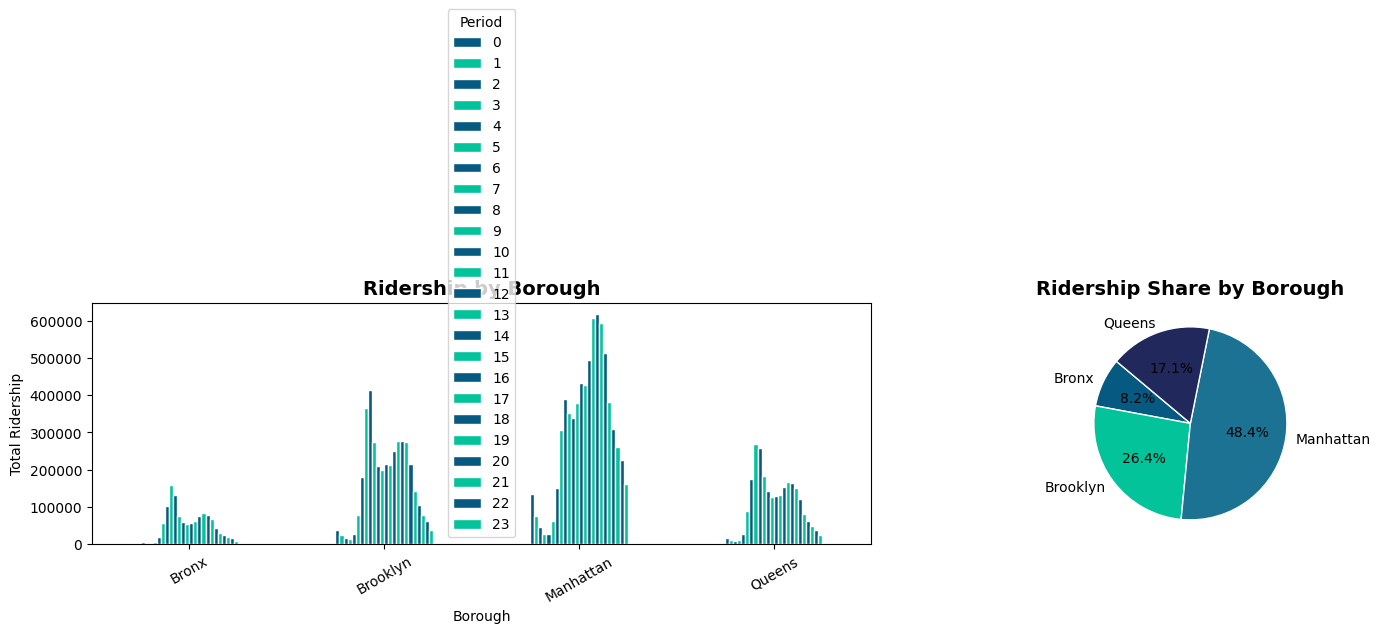


Key Insight: Manhattan accounts for over 48.4% of all subway ridership in this dataset.
Staten Island has the lowest share due to its smaller subway footprint (primarily the SIR).


In [ ]:
borough_period = df_cleaned.groupby(['borough', 'period'])['ridership'].sum().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart: ridership by borough
borough_period.plot(kind='bar', ax=axes[0], color=['#065A82', '#02C39A'], edgecolor='white')
axes[0].set_title('Ridership by Borough', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Borough')
axes[0].set_ylabel('Total Ridership')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Period')

# Pie chart: share of total ridership by borough
borough_total = df_cleaned.groupby('borough')['ridership'].sum()
axes[1].pie(borough_total, labels=borough_total.index, autopct='%1.1f%%',
            colors=['#065A82','#02C39A','#1C7293','#21295C','#6096BA'],
            startangle=140, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Ridership Share by Borough', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nKey Insight: Manhattan accounts for over 48.4% of all subway ridership in this dataset.")
print("Staten Island has the lowest share due to its smaller subway footprint (primarily the SIR).")

###**Key Insight:**

Manhattan accounts for over 48.4% of all subway ridership in this dataset, highlighting its central role in the MTA system.
Staten Island has the lowest share, which is expected given its smaller subway network, primarily served by the Staten Island Railway (SIR).

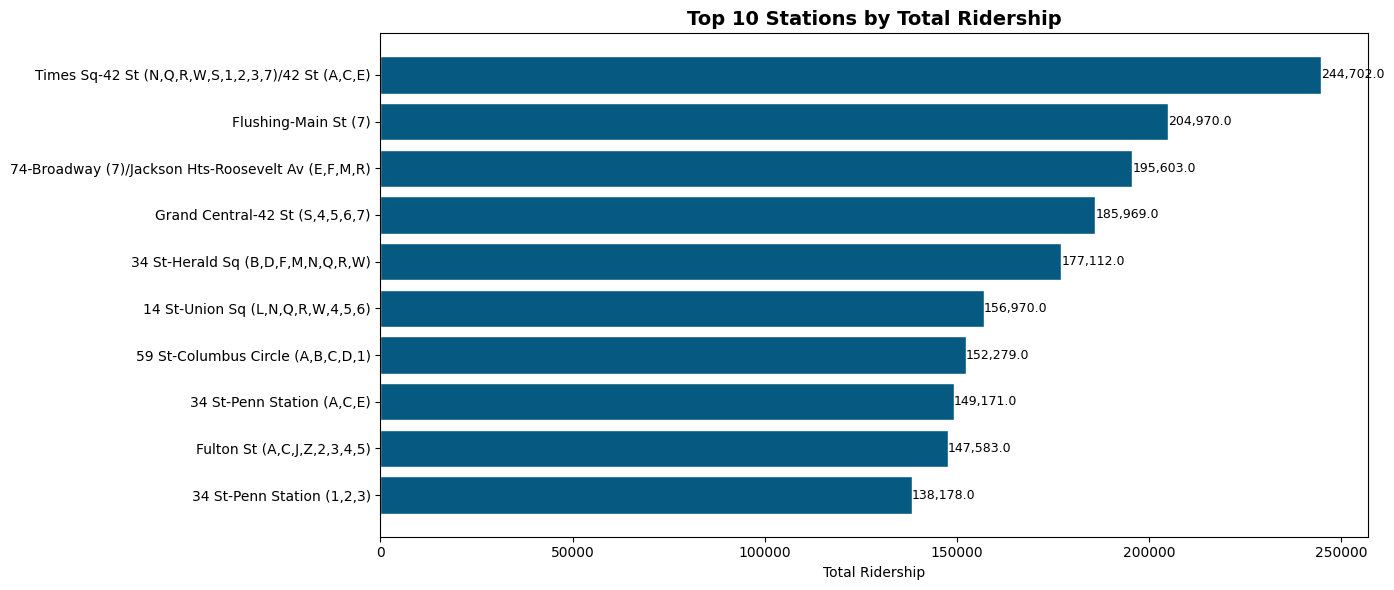

In [ ]:
top10 = df_cleaned.groupby('station_complex')['ridership'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(top10.index[::-1], top10.values[::-1], color='#065A82', edgecolor='white')

# Add value labels
for bar, val in zip(bars, top10.values[::-1]):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.set_title('Top 10 Stations by Total Ridership', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Ridership')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

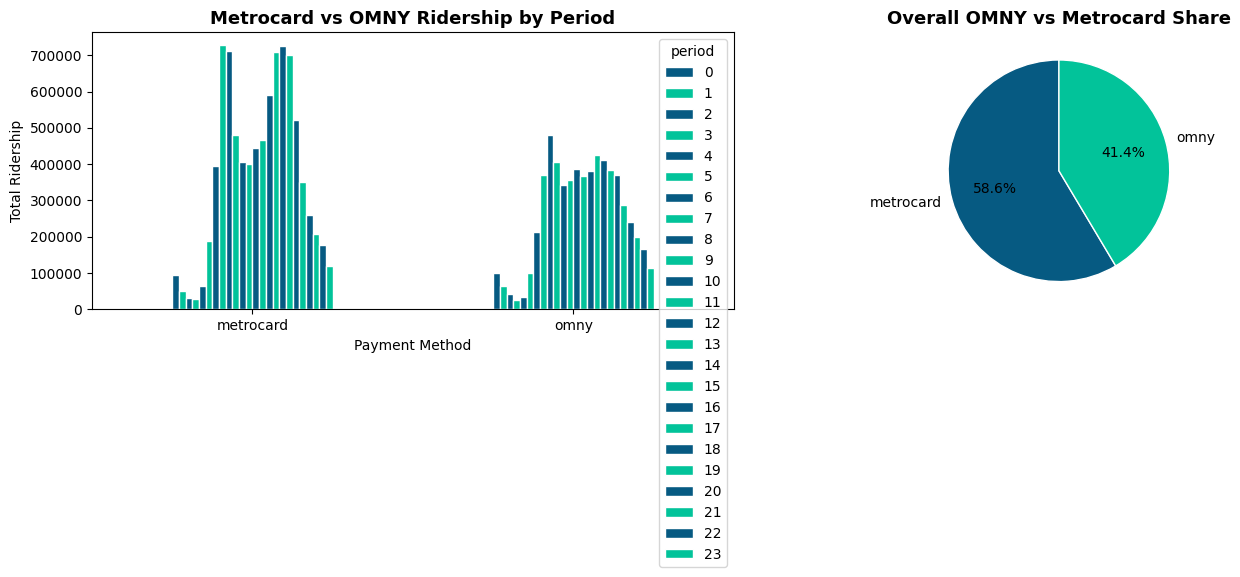

In [ ]:
payment_period = df_cleaned.groupby(['payment_method', 'period'])['ridership'].sum().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grouped bar
payment_period.plot(kind='bar', ax=axes[0], color=['#065A82', '#02C39A'], edgecolor='white')
axes[0].set_title('Metrocard vs OMNY Ridership by Period', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Payment Method')
axes[0].set_ylabel('Total Ridership')
axes[0].tick_params(axis='x', rotation=0)

# Pie
payment_total = df_cleaned.groupby('payment_method')['ridership'].sum()
axes[1].pie(payment_total, labels=payment_total.index, autopct='%1.1f%%',
            colors=['#065A82', '#02C39A'], startangle=90,
            wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Overall OMNY vs Metrocard Share', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

omny_pct = payment_total['omny'] / payment_total.sum() * 100

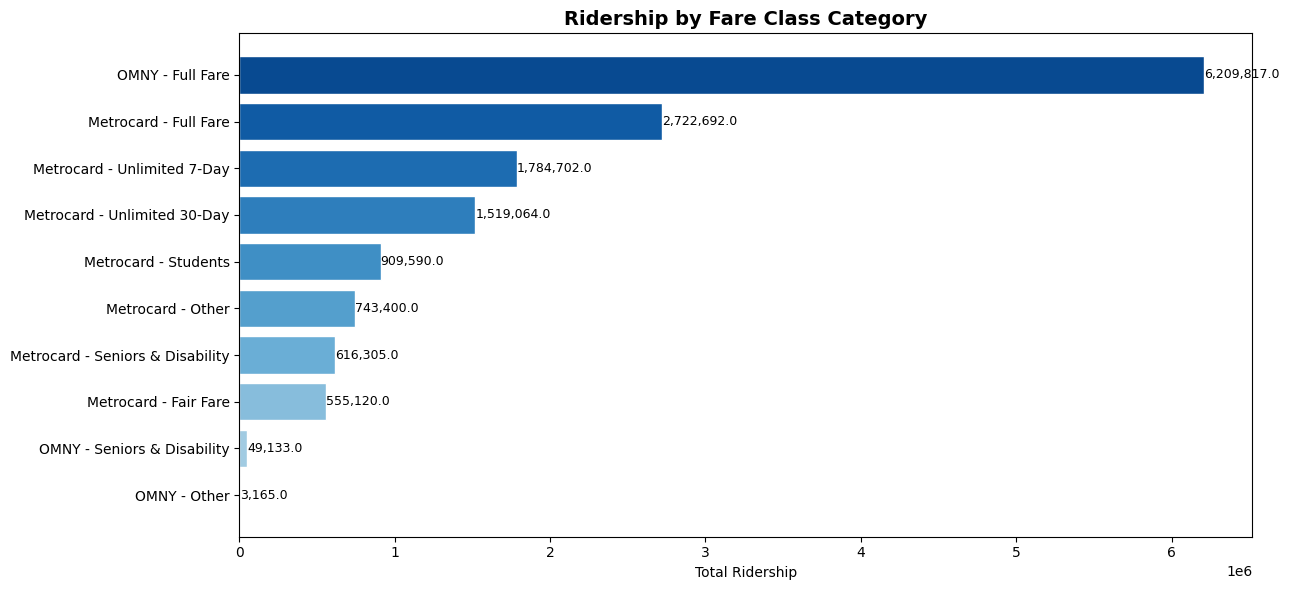

In [ ]:
fare_totals = df_cleaned.groupby('fare_class_category')['ridership'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(13, 6))
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(fare_totals)))
bars = ax.barh(fare_totals.index, fare_totals.values, color=colors, edgecolor='white')

for bar, val in zip(bars, fare_totals.values):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.set_title('Ridership by Fare Class Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Ridership')
plt.tight_layout()
plt.show()

In [ ]:
import folium
import numpy as np
import branca.colormap as cm

# Convert 'ridership' to numeric, coercing errors to NaN
df['ridership'] = pd.to_numeric(df['ridership'], errors='coerce')

# Drop rows where latitude, longitude, or ridership are NaN after conversion
df_cleaned = df.dropna(subset=['latitude', 'longitude', 'ridership']).copy()

# Aggregate data for unique locations
# Sum ridership for each unique combination of lat, lon, station, borough, transit_mode
aggregated_df = df_cleaned.groupby(['latitude', 'longitude', 'station_complex', 'borough', 'transit_mode']).agg(
    total_ridership=('ridership', 'sum')
).reset_index()

# --- Categorize ridership into 4 parts and assign distinct colors ---
# Define bins using quantiles to create four groups (quartiles)
aggregated_df['ridership_category'] = pd.qcut(aggregated_df['total_ridership'], q=4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'], duplicates='drop')

# Define a distinct color for each category
category_colors = {
    'Q1 (Low)': 'green',
    'Q2': 'blue',
    'Q3': 'orange',
    'Q4 (High)': 'red'
}

# Create a Folium map centered around the average latitude and longitude
map_center_lat = aggregated_df['latitude'].mean()
map_center_lon = aggregated_df['longitude'].mean()
m = folium.Map(location=[map_center_lat, map_center_lon], zoom_start=12)

# Create a dictionary to hold FeatureGroups for each borough
borough_feature_groups = {}
for borough in aggregated_df['borough'].unique():
    borough_feature_groups[borough] = folium.FeatureGroup(name=borough)
    m.add_child(borough_feature_groups[borough])

# Add markers to the map, categorized by borough
for idx, row in aggregated_df.iterrows():
    # Assign a color based on the ridership category
    marker_color = category_colors.get(row['ridership_category'], 'gray') # Default to gray if category not found

    # Create tooltip HTML
    tooltip_html = f"""
    <b>Station:</b> {row['station_complex']}<br>
    <b>Borough:</b> {row['borough']}<br>
    <b>Transit Mode:</b> {row['transit_mode']}<br>
    <b>Total Ridership:</b> {int(row['total_ridership'])} ({row['ridership_category']})
    """

    # Add the marker to the appropriate borough's FeatureGroup
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5, # Adjust radius as needed
        color=marker_color,
        fill=True,
        fill_color=marker_color,
        fill_opacity=0.7,
        tooltip=tooltip_html
    ).add_to(borough_feature_groups[row['borough']]) # Add to FeatureGroup instead of directly to map

# Add a custom HTML legend to the map
html_legend = """
<div style="position: fixed;
            bottom: 50px; left: 50px; width: 160px; height: 160px;
            border:2px solid grey; z-index:9999; font-size:14px;
            background-color:white; opacity:0.9;">
  &nbsp; <b>Ridership Categories</b> <br>
  &nbsp; <i style="background:green; opacity:0.9; width:15px; height:15px; display:inline-block; vertical-align:middle;"></i> Q1 (Low Ridership) <br>
  &nbsp; <i style="background:blue; opacity:0.9; width:15px; height:15px; display:inline-block; vertical-align:middle;"></i> Q2 <br>
  &nbsp; <i style="background:orange; opacity:0.9; width:15px; height:15px; display:inline-block; vertical-align:middle;"></i> Q3 <br>
  &nbsp; <i style="background:red; opacity:0.9; width:15px; height:15px; display:inline-block; vertical-align:middle;"></i> Q4 (High Ridership)
</div>
"""
m.get_root().html.add_child(folium.Element(html_legend))

# Add LayerControl to the map for toggling boroughs
folium.LayerControl().add_to(m)

# Display the map directly in the Colab notebook
display(m)

### Preparing Data for Time Series Analysis and Seasonal Decomposition

To prepare the data for seasonal decomposition and subsequent forecasting, we'll first aggregate the ridership data to an hourly level. This involves:

1.  **Extracting Date Components**: We'll ensure we are working with hourly data for decomposition.
2.  **Aggregating Hourly Ridership**: Summing ridership for each hour across all stations.
3.  **Handling Missing Dates**: For accurate time series analysis, we need a continuous time series. We will resample the data to hourly frequency and fill any missing values.
4.  **Seasonal Decomposition**: Applying the seasonal decompose function from statsmodels to break down the time series into its trend, seasonal, and residual components. This helps in understanding the underlying patterns.

In [ ]:
# Aggregate hourly ridership
# First, ensure transit_timestamp is the index for resampling
df_hourly_raw = df_cleaned.set_index('transit_timestamp')

# Resample to hourly frequency and sum ridership
hourly_ridership = df_hourly_raw['ridership'].resample('h').sum().reset_index()
hourly_ridership = hourly_ridership.set_index('transit_timestamp')

# Fill any potential missing hours with 0 or an appropriate method if needed
# For simplicity, we'll assume continuous data after resampling and summing.
# If there are gaps in the original timestamps, resample('h').sum() will fill them with 0, which is appropriate for ridership.

print("Hourly Ridership Head:")
display(hourly_ridership.head())
print("\nHourly Ridership Info:")
hourly_ridership.info()

Hourly Ridership Head:


,ridership
transit_timestamp,
2024-01-01 00:00:00,62253.0
2024-01-01 01:00:00,58419.0
2024-01-01 02:00:00,38751.0
2024-01-01 03:00:00,19515.0
2024-01-01 04:00:00,13810.0



Hourly Ridership Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 157 entries, 2024-01-01 00:00:00 to 2024-01-07 12:00:00
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ridership  157 non-null    float64
dtypes: float64(1)
memory usage: 2.5 KB


Not enough data points for reliable weekly seasonal decomposition (period=168).
Number of data points: 157. Minimum required: 336 hours.
Attempting daily seasonal decomposition instead (period=24) if enough data is available.


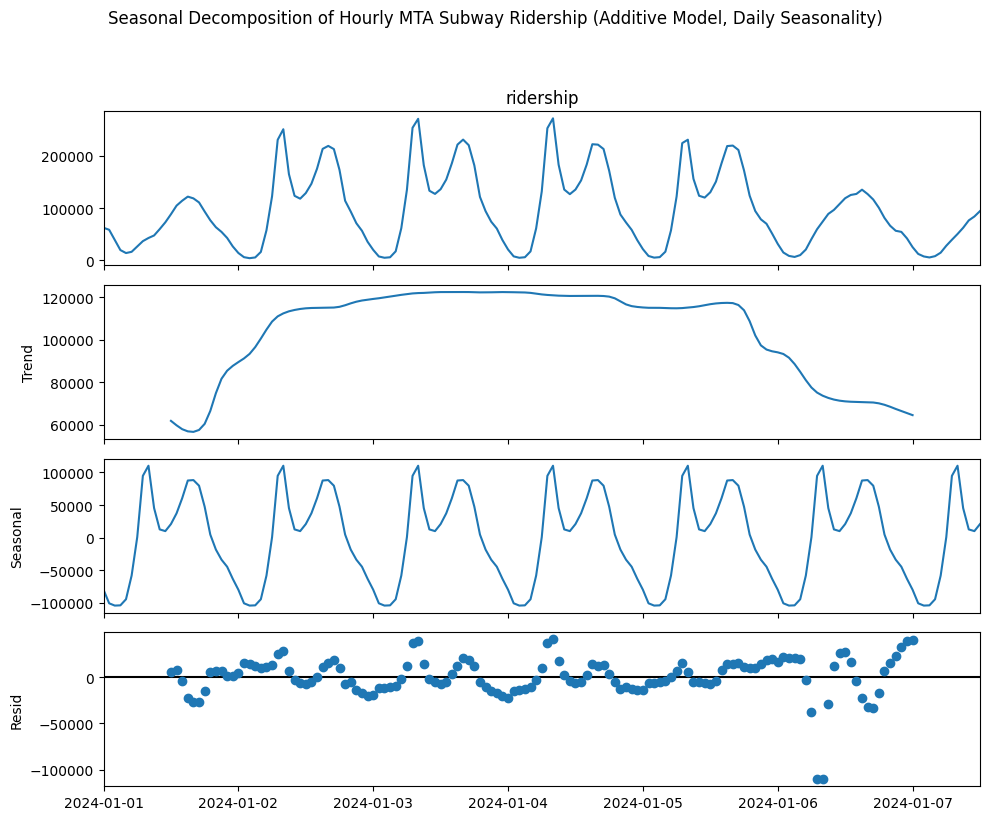

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Define the period for seasonal decomposition.
# For hourly data, if we expect weekly seasonality, the period would be 24 hours/day * 7 days/week = 168 hours.
# If we expect daily seasonality, the period would be 24 hours.
# Given transit patterns, weekly seasonality is often more pronounced over longer periods, but requires more data.

period_weekly = 24 * 7 # 168 hours for weekly seasonality
period_daily = 24 # 24 hours for daily seasonality

# Check the number of data points to ensure enough data for decomposition with weekly period
if len(hourly_ridership) < 2 * period_weekly: # Need at least two periods for reliable decomposition
    print(f"Not enough data points for reliable weekly seasonal decomposition (period={period_weekly}).")
    print(f"Number of data points: {len(hourly_ridership)}. Minimum required: {2 * period_weekly} hours.")
    print(f"Attempting daily seasonal decomposition instead (period={period_daily}) if enough data is available.")
    # Fallback to daily seasonality if not enough data for weekly
    if len(hourly_ridership) < 2 * period_daily:
        print(f"Not enough data points for reliable daily seasonal decomposition (period={period_daily}) either.")
        print(f"Number of data points: {len(hourly_ridership)}. Minimum required: {2 * period_daily} hours.")
    else:
        decomposition = seasonal_decompose(hourly_ridership['ridership'], model='additive', period=period_daily) # Assuming daily seasonality
        fig = decomposition.plot()
        fig.set_size_inches(10, 8)
        plt.suptitle('Seasonal Decomposition of Hourly MTA Subway Ridership (Additive Model, Daily Seasonality)', y=1.02) # Add a main title
        plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent title overlap
        plt.show()
else:
    decomposition = seasonal_decompose(hourly_ridership['ridership'], model='additive', period=period_weekly) # Assuming weekly seasonality

    # Plot the decomposed components
    fig = decomposition.plot()
    fig.set_size_inches(10, 8)
    plt.suptitle('Seasonal Decomposition of Hourly MTA Subway Ridership (Additive Model, Weekly Seasonality)', y=1.02) # Add a main title
    plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent title overlap
    plt.show()

The seasonal decomposition plot visually separates the hourly time series into its trend, seasonal, and residual components. This helps in understanding:

*   **Trend**: The long-term progression of the series.
*   **Seasonal**: The recurring patterns within a fixed period (e.g., daily or weekly in hourly data).
*   **Residual**: The random, irregular component remaining after removing the trend and seasonal effects.

### Data Scaling (Min-Max Normalization)
The use of scaling is optional when using Holt-Winters and Prophet methods; however, it is an industry standard for machine learning techniques; such as Random Forest and XGBoost as they require consistent data ranges. Scaling can ensure that all data values fall within an equal range (e.g. 0-1) so that no single attribute is able to dictate the outcome of the model due to it's large value. Here, we show the example of using Min-Max normalization on the ridership data.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Create a copy of the hourly_ridership DataFrame to store scaled data
hourly_ridership_scaled = hourly_ridership.copy()

# Apply Min-Max scaling to the 'ridership' column
hourly_ridership_scaled['ridership_scaled'] = scaler.fit_transform(hourly_ridership_scaled[['ridership']])

# Display the head of the DataFrame with the new scaled column
print("Hourly Ridership with Scaled Data Head:")
display(hourly_ridership_scaled.head())

# You can also get the inverse transform if you need to convert scaled values back to original scale
# original_values = scaler.inverse_transform(hourly_ridership_scaled[['ridership_scaled']])

Hourly Ridership with Scaled Data Head:


,ridership,ridership_scaled
transit_timestamp,,
2024-01-01 00:00:00,62253.0,0.217438
2024-01-01 01:00:00,58419.0,0.203137
2024-01-01 02:00:00,38751.0,0.129772
2024-01-01 03:00:00,19515.0,0.058019
2024-01-01 04:00:00,13810.0,0.036738


### Model-1 Holt-Winters Exponential Smoothing for Hourly Ridership

We will now apply the Holt-Winters Exponential Smoothing method to forecast hourly ridership. This method is suitable for time series data exhibiting both trend and seasonality. For our hourly data, we will consider a daily seasonality, meaning the seasonal component repeats every 24 hours.

1.  **Define the Model**: We'll use ExponentialSmoothing from statsmodels, specifying an additive trend and additive seasonality.
2.  **Fit the Model**: The model will be fitted to the hourly_ridership data.
3.  **Forecast**: We'll generate a forecast for a short future period.
4.  **Visualize**: The original data, the fitted values from the model, and the forecast will be plotted to assess the model's performance.

In [ ]:
# Define the Holt-Winters Exponential Smoothing model
# We assume additive trend and additive seasonality (since ridership won't go below zero significantly)
# Seasonal period is 24 for hourly daily seasonality.
# The model needs enough data for the seasonal period, which we have for 24 hours.

# Ensure the index is a DatetimeIndex before applying ExponentialSmoothing
if not isinstance(hourly_ridership.index, pd.DatetimeIndex):
    hourly_ridership.index = pd.to_datetime(hourly_ridership.index)

fit_hw = ExponentialSmoothing(hourly_ridership['ridership'], seasonal_periods=24, trend='add', seasonal='add', initialization_method="estimated").fit()

# Generate in-sample fitted values
hourly_ridership['HoltWinters'] = fit_hw.fittedvalues

# Generate a forecast for the next 24 hours
forecast_horizon = 24
forecast_hw = fit_hw.forecast(forecast_horizon)

print("Holt-Winters Model Summary:")
print(fit_hw.summary())

print("\nHolt-Winters Forecast (next 24 hours):")
display(forecast_hw)

Holt-Winters Model Summary:
                       ExponentialSmoothing Model Results                       
Dep. Variable:                ridership   No. Observations:                  157
Model:             ExponentialSmoothing   SSE                    82934528348.626
Optimized:                         True   AIC                           3209.356
Trend:                         Additive   BIC                           3294.931
Seasonal:                      Additive   AICC                          3224.118
Seasonal Periods:                    24   Date:                 Mon, 04 May 2026
Box-Cox:                          False   Time:                         21:05:29
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               1.0000000                alpha                 Tr

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


,0
2024-01-07 13:00:00,113726.044503
2024-01-07 14:00:00,140299.367175
2024-01-07 15:00:00,170734.080781
2024-01-07 16:00:00,174126.408887
2024-01-07 17:00:00,166188.398583
2024-01-07 18:00:00,132237.565264
2024-01-07 19:00:00,87656.148847
2024-01-07 20:00:00,61553.217677
2024-01-07 21:00:00,44198.642566
2024-01-07 22:00:00,32052.631660


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


                       ExponentialSmoothing Model Results                       
Dep. Variable:                ridership   No. Observations:                  125
Model:             ExponentialSmoothing   SSE                    41589719745.037
Optimized:                         True   AIC                           2508.851
Trend:                         Additive   BIC                           2588.043
Seasonal:                      Additive   AICC                          2528.638
Seasonal Periods:                    24   Date:                 Mon, 04 May 2026
Box-Cox:                          False   Time:                         21:13:42
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               1.0000000                alpha                 True
smoothing_trend          

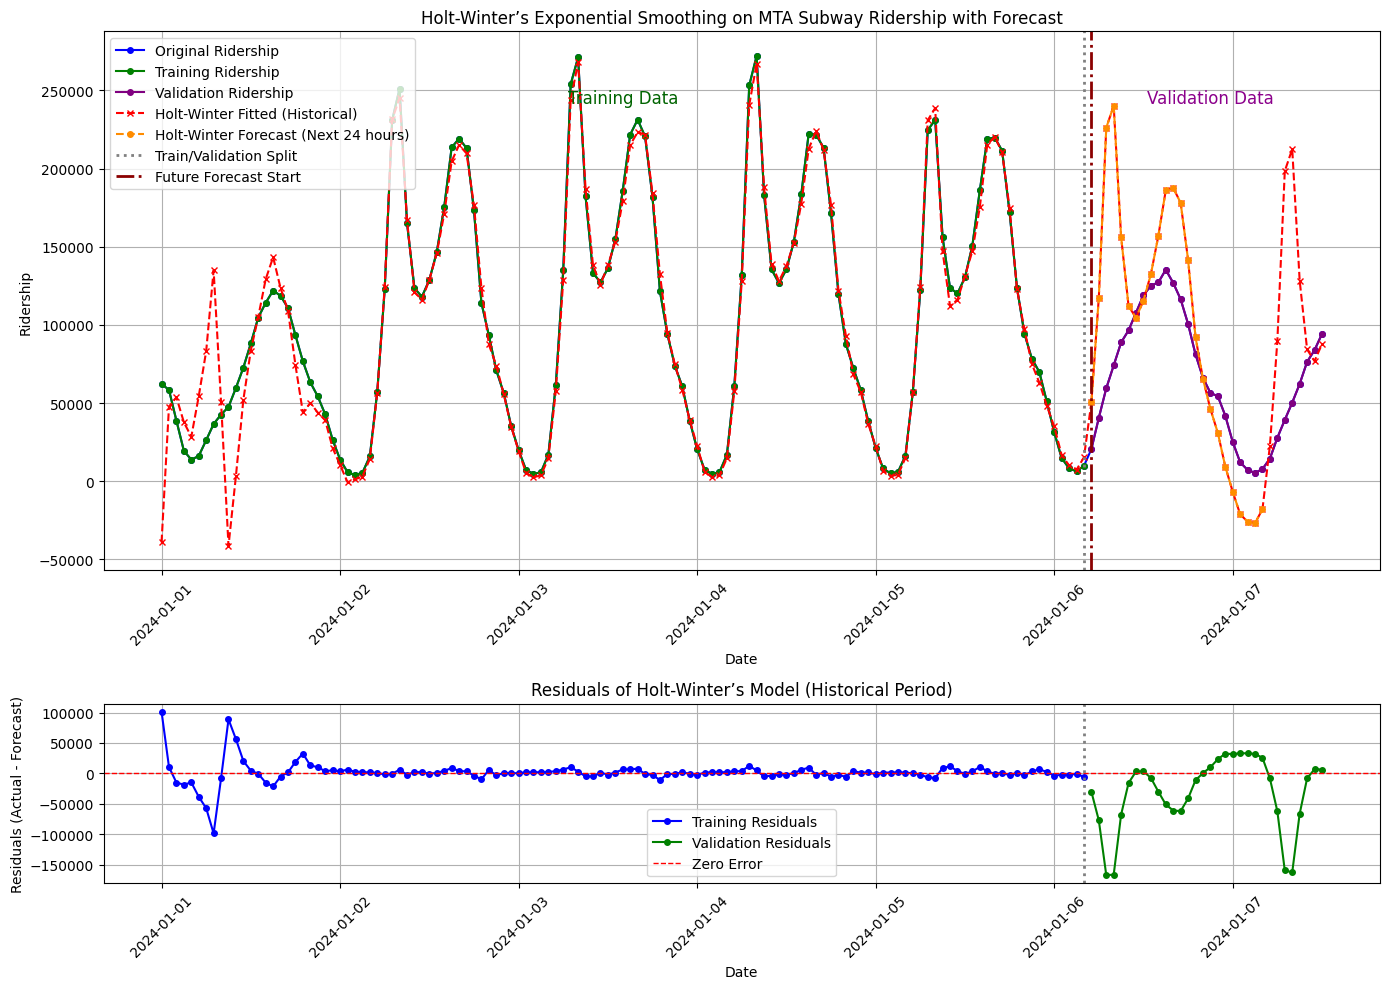

In [ ]:
# Define the split point for training and validation
# Let's use the first 80% for training and the last 20% for validation
split_point = int(len(hourly_ridership) * 0.8)
train_hourly_ridership = hourly_ridership.iloc[:split_point]
valid_hourly_ridership = hourly_ridership.iloc[split_point:]

# Apply Holt-Winter's exponential smoothing to the training data
# We'll use additive trend and additive seasonality, as done previously for hourly data
# seasonal_periods=24 for hourly daily seasonality
hw_model = ExponentialSmoothing(
    train_hourly_ridership['ridership'],
    seasonal_periods=24,
    trend='add',
    seasonal='add',
    initialization_method="estimated" # Let the model estimate initial values
)

# Fit the model without specifying smoothing parameters to let them be optimized
hw_fit = hw_model.fit()

# Print the model summary
print(hw_fit.summary())

# Generate forecasts for the entire series length (training + validation)
# The forecast 'start' and 'end' points should cover the period we want to predict over
# This includes the training period for fitted values and the validation period for actual forecasts
hw_forecast_in_sample = hw_fit.predict(start=hourly_ridership.index[0], end=hourly_ridership.index[-1])

# Generate forecast for the next 24 hours beyond the historical data
future_forecast_steps = 24
hw_forecast_future = hw_fit.forecast(steps=future_forecast_steps)

# Combine in-sample forecast with future forecast for plotting
combined_hw_forecast = pd.concat([hw_forecast_in_sample, hw_forecast_future])

# Calculate residuals for the training and validation sets
train_residuals_hw = train_hourly_ridership['ridership'] - hw_forecast_in_sample.loc[train_hourly_ridership.index]
valid_residuals_hw = valid_hourly_ridership['ridership'] - hw_forecast_in_sample.loc[valid_hourly_ridership.index]

# Create a figure with two subplots: one for the main plot and one for residuals
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})

# Plot 1: Main plot with original, training, validation, and forecast data
axes[0].plot(hourly_ridership.index, hourly_ridership['ridership'], label='Original Ridership', color='blue', marker='o', markersize=4)
axes[0].plot(train_hourly_ridership.index, train_hourly_ridership['ridership'], label='Training Ridership', color='green', marker='o', markersize=4)
axes[0].plot(valid_hourly_ridership.index, valid_hourly_ridership['ridership'], label='Validation Ridership', color='purple', marker='o', markersize=4)
axes[0].plot(hw_forecast_in_sample.index, hw_forecast_in_sample, label='Holt-Winter Fitted (Historical)', color='red', linestyle='--', marker='x', markersize=4)
axes[0].plot(hw_forecast_future.index, hw_forecast_future, label=f'Holt-Winter Forecast (Next {future_forecast_steps} hours)', color='darkorange', linestyle='--', marker='o', markersize=4)

# Add a vertical line to clearly mark the partition point
partition_date = train_hourly_ridership.index[-1]
axes[0].axvline(x=partition_date, color='gray', linestyle=':', linewidth=2, label='Train/Validation Split')

# Add a vertical line to mark the start of the future forecast
future_forecast_start_date = hw_forecast_future.index[0]
axes[0].axvline(x=future_forecast_start_date, color='darkred', linestyle='-.', linewidth=2, label='Future Forecast Start')

# Add text annotations for training and validation sections
train_text_x = train_hourly_ridership.index[len(train_hourly_ridership) // 2]
valid_text_x = valid_hourly_ridership.index[len(valid_hourly_ridership) // 2]
y_max = hourly_ridership['ridership'].max()
y_min = hourly_ridership['ridership'].min()
text_y_position = y_min + (y_max - y_min) * 0.9

axes[0].text(train_text_x, text_y_position, 'Training Data', color='darkgreen', fontsize=12, ha='center', va='center')
axes[0].text(valid_text_x, text_y_position, 'Validation Data', color='darkmagenta', fontsize=12, ha='center', va='center')

axes[0].set_title('Holt-Winter’s Exponential Smoothing on MTA Subway Ridership with Forecast')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Ridership')
axes[0].legend()
axes[0].grid(True)
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Residuals plot (only for historical data)
axes[1].plot(train_residuals_hw.index, train_residuals_hw, label='Training Residuals', color='blue', marker='o', markersize=4, linestyle='-')
axes[1].plot(valid_residuals_hw.index, valid_residuals_hw, label='Validation Residuals', color='green', marker='o', markersize=4, linestyle='-')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1, label='Zero Error')
axes[1].axvline(x=partition_date, color='gray', linestyle=':', linewidth=2)
axes[1].set_title('Residuals of Holt-Winter’s Model (Historical Period)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Residuals (Actual - Forecast)')
axes[1].legend()
axes[1].grid(True)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

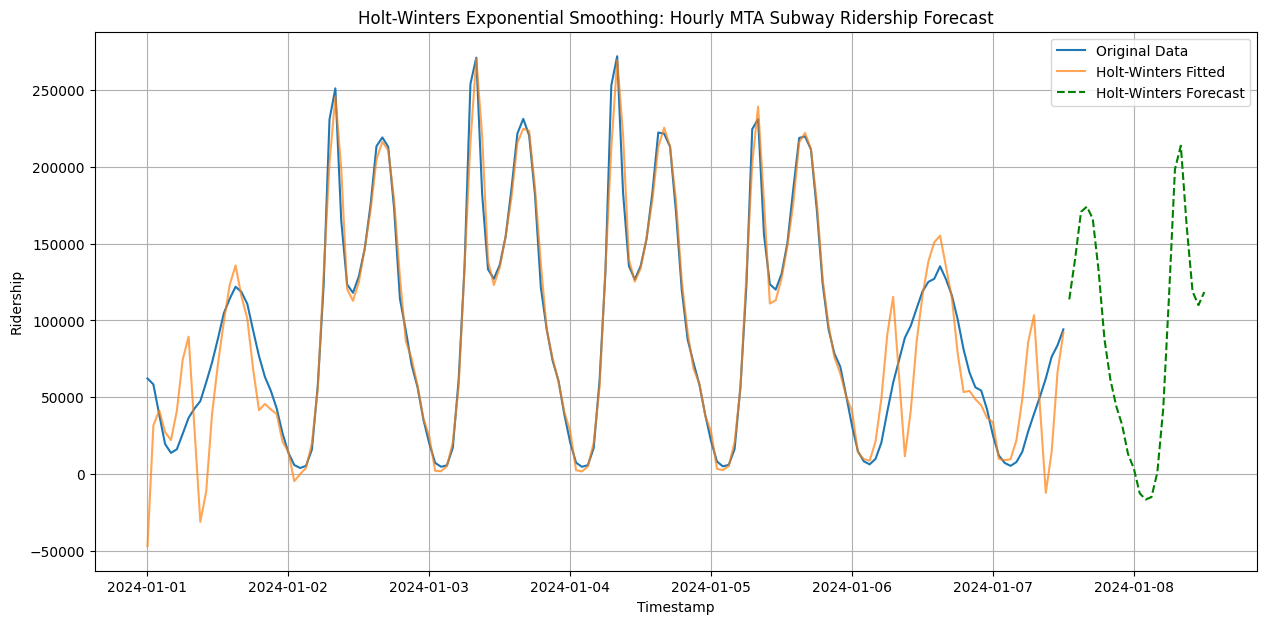

In [ ]:
# Plot the original data, fitted values, and forecast
plt.figure(figsize=(15, 7))
plt.plot(hourly_ridership['ridership'], label='Original Data')
plt.plot(hourly_ridership['HoltWinters'], label='Holt-Winters Fitted', alpha=0.7)
plt.plot(forecast_hw, label='Holt-Winters Forecast', color='green', linestyle='--')

plt.title('Holt-Winters Exponential Smoothing: Hourly MTA Subway Ridership Forecast')
plt.xlabel('Timestamp')
plt.ylabel('Ridership')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print("Holt-Winters Forecast for the next 24 hours:")
display(forecast_hw)

Holt-Winters Forecast for the next 24 hours:


,0
2024-01-07 13:00:00,113726.044503
2024-01-07 14:00:00,140299.367175
2024-01-07 15:00:00,170734.080781
2024-01-07 16:00:00,174126.408887
2024-01-07 17:00:00,166188.398583
2024-01-07 18:00:00,132237.565264
2024-01-07 19:00:00,87656.148847
2024-01-07 20:00:00,61553.217677
2024-01-07 21:00:00,44198.642566
2024-01-07 22:00:00,32052.631660


###**Model 2: Prophet**

Prophet from Meta is intended for commercial time series with significant seasonality and holidays; it can also automatically detect and account for change points in the trend and is capable of imputing missing data. Prophet works on a DataFrame containing ds (dates) and y (values). Due to its ease of use and interpretative ability, Prophet has gained quite a bit of popularity within commercial organizations.

Traceback (most recent call last):
  File "/usr/local/bin/pip3", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/main.py", line 78, in main
    command = create_command(cmd_name, isolated=("--isolated" in cmd_args))
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/__init__.py", line 114, in create_command
    module = importlib.import_module(module_path)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/importlib/__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1331, in _find_and_load_unloc

,ds,y,HoltWinters
0,2024-01-01 00:00:00,62253.0,-46961.749418
1,2024-01-01 01:00:00,58419.0,31622.715295
2,2024-01-01 02:00:00,38751.0,41547.061097
3,2024-01-01 03:00:00,19515.0,27308.204647
4,2024-01-01 04:00:00,13810.0,22145.420833



Prophet Forecast Head:


,ds,yhat,yhat_lower,yhat_upper
0,2024-01-01 00:00:00,12257.349392,-19852.911298,42668.660555
1,2024-01-01 01:00:00,7760.504967,-22044.237179,38338.333990
2,2024-01-01 02:00:00,1088.755300,-27899.795051,30626.345462
3,2024-01-01 03:00:00,-2384.660642,-33404.275870,27188.310300
4,2024-01-01 04:00:00,5285.568687,-24911.205266,35589.223539


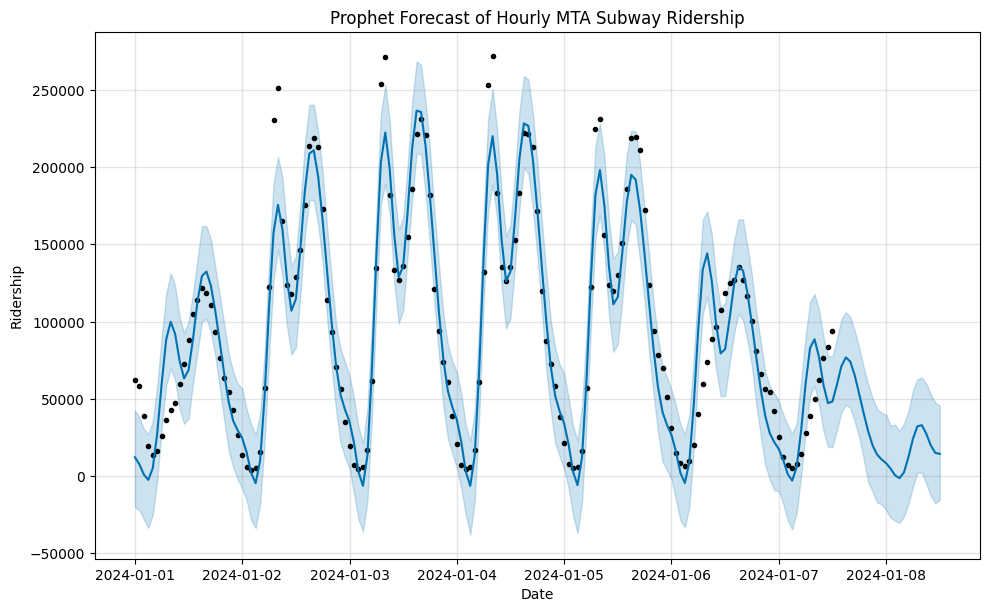

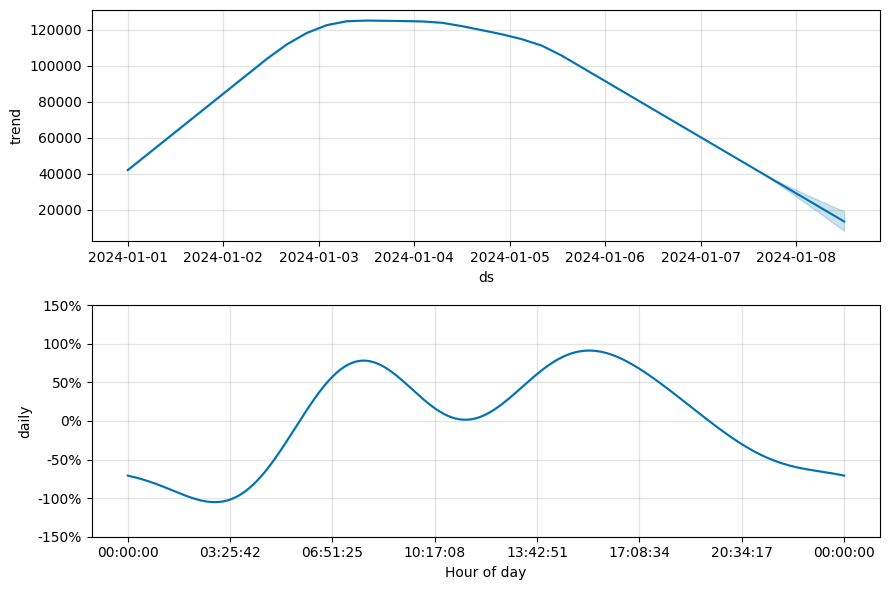

In [ ]:
# Install Prophet library
!pip install prophet

# Import necessary libraries
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

# Prepare the data for Prophet
# Prophet requires the dataframe to have two columns: 'ds' (datetime) and 'y' (numeric value)
prophet_df = hourly_ridership.reset_index().rename(columns={'transit_timestamp': 'ds', 'ridership': 'y'})

# Display the head of the prepared data
print("Prophet Data Head:")
display(prophet_df.head())

# Initialize and fit the Prophet model
# Prophet can automatically detect daily seasonality if enough data is provided.
# Given our data is hourly, we can specify daily seasonality.
model = Prophet(
    seasonality_mode='multiplicative', # Can be 'additive' or 'multiplicative'
    daily_seasonality=True,     # Enable daily seasonality
    weekly_seasonality=False,    # Disable weekly seasonality, as our data is less than 7 days
    yearly_seasonality=False    # Disable yearly seasonality
)

# Fit the model to the data
model.fit(prophet_df)

# Create a future dataframe for forecasting
# We'll forecast for the next 24 hours (1 day)
future = model.make_future_dataframe(periods=24, freq='h')

# Generate the forecast
forecast = model.predict(future)

# Display the forecast components
print("\nProphet Forecast Head:")
display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

# Plot the forecast
fig = model.plot(forecast)
plt.title('Prophet Forecast of Hourly MTA Subway Ridership')
plt.xlabel('Date')
plt.ylabel('Ridership')
plt.show()

# Plot the forecast components (trend, daily seasonality)
fig2 = model.plot_components(forecast)
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error

# Merge actuals with forecasts for evaluation
eval_df = pd.merge(prophet_df, forecast[['ds', 'yhat']], on='ds', how='inner')

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(eval_df['y'], eval_df['yhat'])
print(f"Mean Squared Error (MSE) of Prophet forecast: {mse:.2f}")

Mean Squared Error (MSE) of Prophet forecast: 548885996.01


###**Model 3: SARIMAX**
The seasonal autoregressive integrated moving average (SARIMAX) model incorporates an external factor to identify when a series is correlated to itself at an earlier time point in the past; hence, it predicts future data points by using historical values as predictors. The seasonal (S) measure of the SARIMAX series is used because of the cyclical nature of the data. Typical order criteria for daily transit data include (1,1,1) ,with an assumed 7 day seasonal cycle.

In [ ]:
import itertools
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd

# Define the p, d, q parameters for ARIMA
p = d = q = range(0, 3) # Example: 0, 1, 2

# Define the P, D, Q parameters for Seasonal ARIMA
P = D = Q = range(0, 2) # Example: 0, 1
S = 24 # Seasonal period (daily seasonality for hourly data)

# Create all possible combinations of ARIMA (p, d, q) and Seasonal ARIMA (P, D, Q, S) orders
# Non-seasonal combinations
pdq = list(itertools.product(p, d, q))

# Seasonal combinations
seasonal_pdq = [(x[0], x[1], x[2], S) for x in list(itertools.product(P, D, Q))]

warnings.filterwarnings("ignore") # Ignore convergence warnings

best_aic = float("inf")
best_order = None
best_seasonal_order = None
best_sarimax_model = None

# Prepare the training data for SARIMAX
# Assuming 'hourly_ridership' is already defined from previous cells
split_point = int(len(hourly_ridership) * 0.8)
train_sarimax = hourly_ridership.iloc[:split_point]['ridership']

print('Performing SARIMAX Grid Search...')
for order in pdq:
    for seasonal_order in seasonal_pdq:
        try:
            # Fit the SARIMAX model with current parameters
            model = SARIMAX(train_sarimax, # Use the training data
                            order=order,
                            seasonal_order=seasonal_order,
                            enforce_stationarity=False, # Enforce stationarity
                            enforce_invertibility=False) # Enforce invertibility
            results = model.fit(disp=False)

            # Evaluate using AIC (Akaike Information Criterion)
            if results.aic < best_aic:
                best_aic = results.aic
                best_order = order
                best_seasonal_order = seasonal_order
                best_sarimax_model = results

        except Exception as e:
            # print(f"Error with order {order} and seasonal order {seasonal_order}: {e}") # Uncommented for debugging
            continue

print('\nSARIMAX Grid Search Complete.')
print(f"Best SARIMAX Order: {best_order}")
print(f"Best Seasonal SARIMAX Order: {best_seasonal_order}")
print(f"Best AIC: {best_aic:.2f}")

# You can now use best_sarimax_model for further analysis or forecasting
# For example, to print the summary of the best model:
# print(best_sarimax_model.summary())

Performing SARIMAX Grid Search...

SARIMAX Grid Search Complete.
Best SARIMAX Order: (1, 0, 2)
Best Seasonal SARIMAX Order: (1, 1, 1, 24)
Best AIC: 1462.99


###**Model 3: SARIMAX**

The seasonal autoregressive integrated moving average (SARIMAX) model incorporates an external factor to identify when a series is correlated to itself at an earlier time point in the past; hence, it predicts future data points by using historical values as predictors. The seasonal (S) measure of the SARIMAX series is used because of the cyclical nature of the data. Typical order criteria for daily transit data include (0,1,0) ,with an assumed 7 day seasonal cycle.

SARIMAX Model Summary:
                                      SARIMAX Results                                       
Dep. Variable:                            ridership   No. Observations:                  125
Model:             SARIMAX(1, 0, 2)x(1, 1, [1], 24)   Log Likelihood                -725.497
Date:                              Mon, 04 May 2026   AIC                           1462.995
Time:                                      21:17:51   BIC                           1476.819
Sample:                                  01-01-2024   HQIC                          1468.510
                                       - 01-06-2024                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5912      0.140      4.237      0.000       0.318       0.

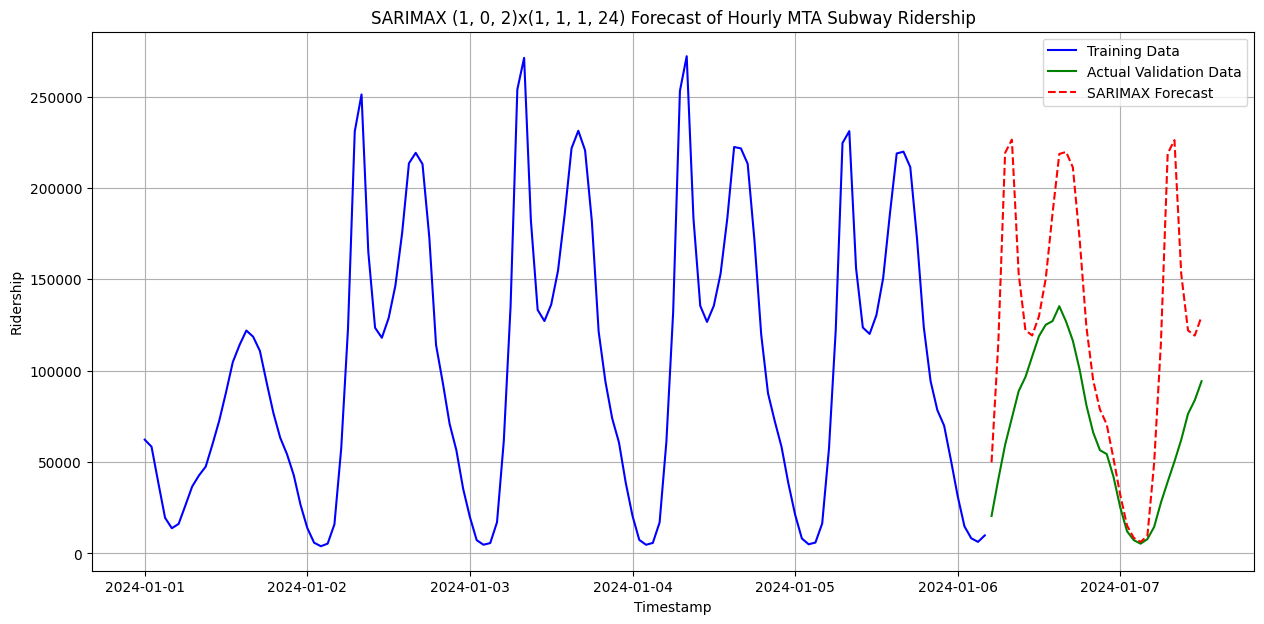

In [ ]:
# Import SARIMAX model
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

# Split data into training and validation sets (same split as previous models)
# 'hourly_ridership' is already defined and indexed by 'transit_timestamp'

split_point = int(len(hourly_ridership) * 0.8)
train_sarimax = hourly_ridership.iloc[:split_point]['ridership']
valid_sarimax = hourly_ridership.iloc[split_point:]['ridership']

# Define the SARIMAX order (p, d, q) and seasonal order (P, D, Q, S)
# For hourly data with daily seasonality, S=24
# (p,d,q) - non-seasonal order
# (P,D,Q,S) - seasonal order
order = (1, 0, 2)        # Non-seasonal (p, d, q)
seasonal_order = (1, 1, 1, 24) # Seasonal (P, D, Q, S) - S=24 for daily seasonality

# Fit the SARIMAX model on the training data
# Enforce stationarity and invertibility for model stability
model_sarimax = SARIMAX(train_sarimax, order=order, seasonal_order=seasonal_order,
                        enforce_stationarity=False, enforce_invertibility=False)
model_sarimax_fit = model_sarimax.fit(disp=False) # disp=False to suppress optimization output

print("SARIMAX Model Summary:")
print(model_sarimax_fit.summary())

# Make predictions on the validation set
# start and end parameters for prediction
start_index_sarimax = len(train_sarimax)
end_index_sarimax = len(hourly_ridership) - 1

# Get index for validation set to align predictions
forecast_index_sarimax = valid_sarimax.index

# Generate predictions for the validation period
predictions_sarimax = model_sarimax_fit.predict(start=start_index_sarimax, end=end_index_sarimax, typ='levels')
predictions_sarimax.index = forecast_index_sarimax

# Evaluate the model
mse_sarimax = mean_squared_error(valid_sarimax, predictions_sarimax)
print(f'\nMean Squared Error (MSE) for SARIMAX: {mse_sarimax:.2f}')

# Plot the results
plt.figure(figsize=(15, 7))
plt.plot(train_sarimax.index, train_sarimax, label='Training Data', color='blue')
plt.plot(valid_sarimax.index, valid_sarimax, label='Actual Validation Data', color='green')
plt.plot(predictions_sarimax.index, predictions_sarimax, label='SARIMAX Forecast', color='red', linestyle='--')

plt.title(f'SARIMAX {order}x{seasonal_order} Forecast of Hourly MTA Subway Ridership')
plt.xlabel('Timestamp')
plt.ylabel('Ridership')
plt.legend()
plt.grid(True)
plt.show()

###**Model 4: Random Forest with Lag Features**

Random Forest is a machine learning method that is applied differently than traditional statistical modelling methods. When applying the method for a time series forecast, you first convert the forecasting problem into a supervised learning problem (i.e., create lag features) — by using the previous seven days of ridership data as your input features for predicting today's ridership. Random Forest is very tolerant of outlier values and performs well with non-linear relationships.

Shape of X_train: (106, 25)
Shape of X_test: (27, 25)
Shape of y_train: (106,)
Shape of y_test: (27,)

Random Forest Mean Squared Error (MSE): 270947740.38
Random Forest R-squared (R2): 0.84


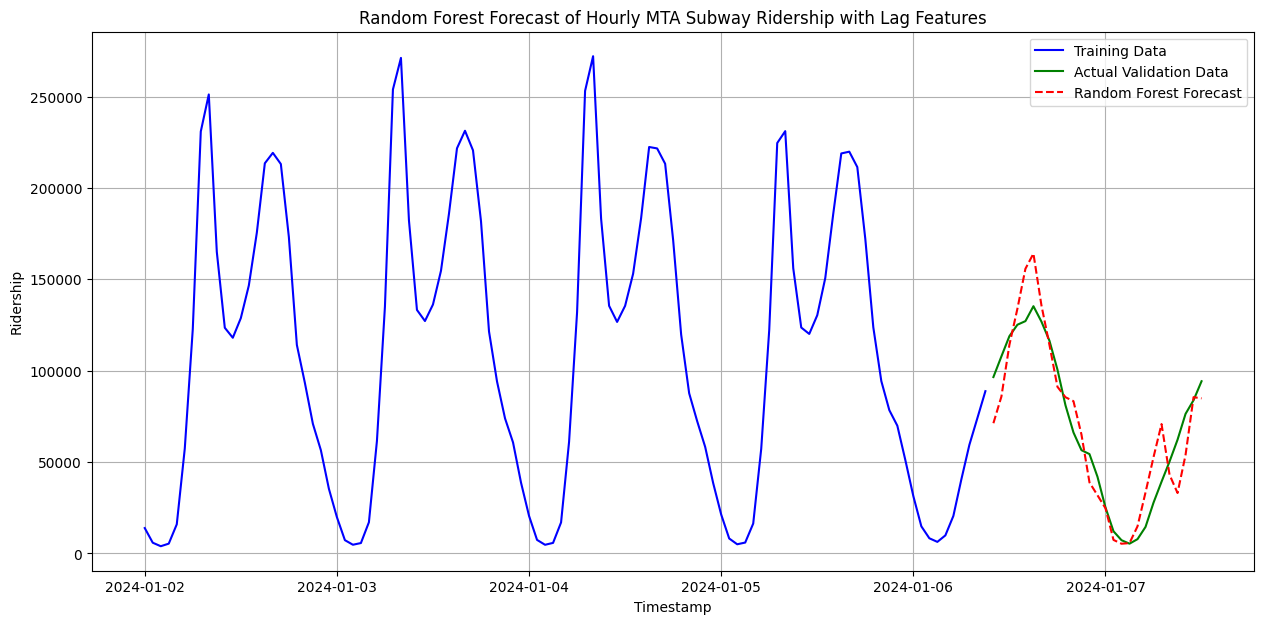

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ensure hourly_ridership is a DataFrame with 'ridership' column and DatetimeIndex
if not isinstance(hourly_ridership, pd.DataFrame):
    # Assuming hourly_ridership might be a Series if previous cells were modified
    hourly_ridership = pd.DataFrame(hourly_ridership)

if 'ridership' not in hourly_ridership.columns:
    # If it's a Series named 'ridership', convert it to DataFrame with 'ridership' column
    hourly_ridership = hourly_ridership.to_frame(name='ridership')

# 1. Create Lag Features
# Let's create lags up to 24 hours to capture daily patterns
num_lags = 24
for i in range(1, num_lags + 1):
    hourly_ridership[f'lag_{i}'] = hourly_ridership['ridership'].shift(i)

# Drop rows with NaN values (which are introduced by the lagging operation)
# These NaNs are at the beginning of the DataFrame where there are no past values
df_lagged = hourly_ridership.dropna()

# 2. Prepare Data for Random Forest
# Define features (X) and target (y)
X = df_lagged.drop('ridership', axis=1) # All lag features are X
y = df_lagged['ridership']            # Current ridership is y

# Split the data into training and testing sets
# Important: For time series, we must preserve the temporal order.
# So, we take the first part for training and the latter for testing.
split_ratio = 0.8
split_index = int(len(X) * split_ratio)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# 3. Implement Random Forest
# Initialize and train the Random Forest Regressor model
# You can tune parameters like n_estimators, max_depth, etc.
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available cores
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# 4. Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\nRandom Forest Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Random Forest R-squared (R2): {r2_rf:.2f}")

# 5. Visualize Results
plt.figure(figsize=(15, 7))
plt.plot(y_train.index, y_train, label='Training Data', color='blue')
plt.plot(y_test.index, y_test, label='Actual Validation Data', color='green')
plt.plot(y_test.index, y_pred_rf, label='Random Forest Forecast', color='red', linestyle='--')

plt.title('Random Forest Forecast of Hourly MTA Subway Ridership with Lag Features')
plt.xlabel('Timestamp')
plt.ylabel('Ridership')
plt.legend()
plt.grid(True)
plt.show()

###**Model 5: XGBoost**

XGBoost is an advanced and powerful version of the Gradient Boosting framework, which allows you to create a series of trees that are not only used for prediction, but also correct the errors produced by prior trees. As with Random Forests, you will use your lagged features as part of your input data so that your forecasting problem can be treated as a regression-type problem.


--- XGBoost Model Implementation ---
XGBoost Mean Squared Error (MSE): 312092895.83
XGBoost R-squared (R2): 0.82


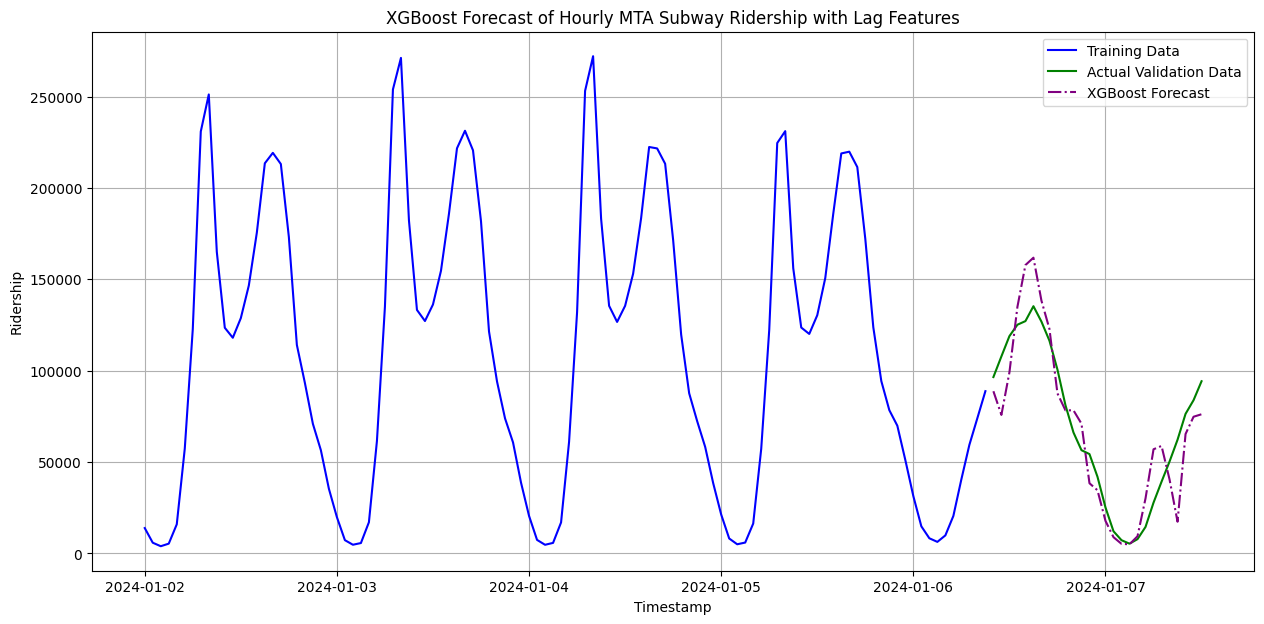

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd

# Ensure X_train, X_test, y_train, y_test are available from previous Random Forest cell
# If not, recreate them:
# if 'X_train' not in globals():
#     # Create Lag Features (if not already done)
#     num_lags = 24
#     for i in range(1, num_lags + 1):
#         hourly_ridership[f'lag_{i}'] = hourly_ridership['ridership'].shift(i)
#     df_lagged = hourly_ridership.dropna()
#     X = df_lagged.drop('ridership', axis=1)
#     y = df_lagged['ridership']
#     split_ratio = 0.8
#     split_index = int(len(X) * split_ratio)
#     X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
#     y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print("\n--- XGBoost Model Implementation ---")

# Initialize and train the XGBoost Regressor model
# Using default parameters, but these can be tuned
xgboost_model = xgb.XGBRegressor(objective='reg:squarederror', # For regression tasks
                                 n_estimators=100,             # Number of boosting rounds
                                 random_state=42,              # For reproducibility
                                 n_jobs=-1)                    # Use all available cores

xgboost_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgboost = xgboost_model.predict(X_test)

# Evaluate the model
mse_xgboost = mean_squared_error(y_test, y_pred_xgboost)
r2_xgboost = r2_score(y_test, y_pred_xgboost)

print(f"XGBoost Mean Squared Error (MSE): {mse_xgboost:.2f}")
print(f"XGBoost R-squared (R2): {r2_xgboost:.2f}")

# Visualize Results
plt.figure(figsize=(15, 7))
plt.plot(y_train.index, y_train, label='Training Data', color='blue')
plt.plot(y_test.index, y_test, label='Actual Validation Data', color='green')
plt.plot(y_test.index, y_pred_xgboost, label='XGBoost Forecast', color='purple', linestyle='-.')

plt.title('XGBoost Forecast of Hourly MTA Subway Ridership with Lag Features')
plt.xlabel('Timestamp')
plt.ylabel('Ridership')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
# Calculate MSE for Holt-Winters on the validation set
from sklearn.metrics import mean_squared_error

# Ensure hw_forecast_in_sample covers the validation period
# hw_forecast_in_sample was generated for the entire series length (training + validation)
# so we can directly compare it to valid_hourly_ridership
mse_hw = mean_squared_error(valid_hourly_ridership['ridership'], hw_forecast_in_sample.loc[valid_hourly_ridership.index])

print("\n--- Model Performance Summary (Mean Squared Error) ---")
print(f"Holt-Winters MSE:      {mse_hw:.2f}")
print(f"Prophet MSE:           {mse:.2f}")
print(f"SARIMAX (1,0,2)x(1,1,1,24) MSE: {mse_sarimax:.2f}")
print(f"Random Forest MSE:     {mse_rf:.2f}")
print(f"XGBoost MSE:           {mse_xgboost:.2f}")
print("----------------------------------------------------")

# You can also create a DataFrame for a cleaner display
model_performance = pd.DataFrame({
    'Model': ['Holt-Winters', 'Prophet', 'SARIMAX (1,0,2)x(1,1,1,24)', 'Random Forest (Lags)', 'XGBoost (Lags)'] ,
    'MSE': [mse_hw, mse, mse_sarimax, mse_rf, mse_xgboost]
})

print("\nModel Performance Table:")
print(model_performance.sort_values(by='MSE', ascending=True).to_markdown(index=False))
# Summary last reviewed/updated: 2026-04-28


--- Model Performance Summary (Mean Squared Error) ---
Holt-Winters MSE:      4575469008.07
Prophet MSE:           548885996.01
SARIMAX (1,0,2)x(1,1,1,24) MSE: 5699995158.32
Random Forest MSE:     270947740.38
XGBoost MSE:           312092895.83
----------------------------------------------------

Model Performance Table:
| Model                      |         MSE |
|:---------------------------|------------:|
| Random Forest (Lags)       | 2.70948e+08 |
| XGBoost (Lags)             | 3.12093e+08 |
| Prophet                    | 5.48886e+08 |
| Holt-Winters               | 4.57547e+09 |
| SARIMAX (1,0,2)x(1,1,1,24) | 5.7e+09     |


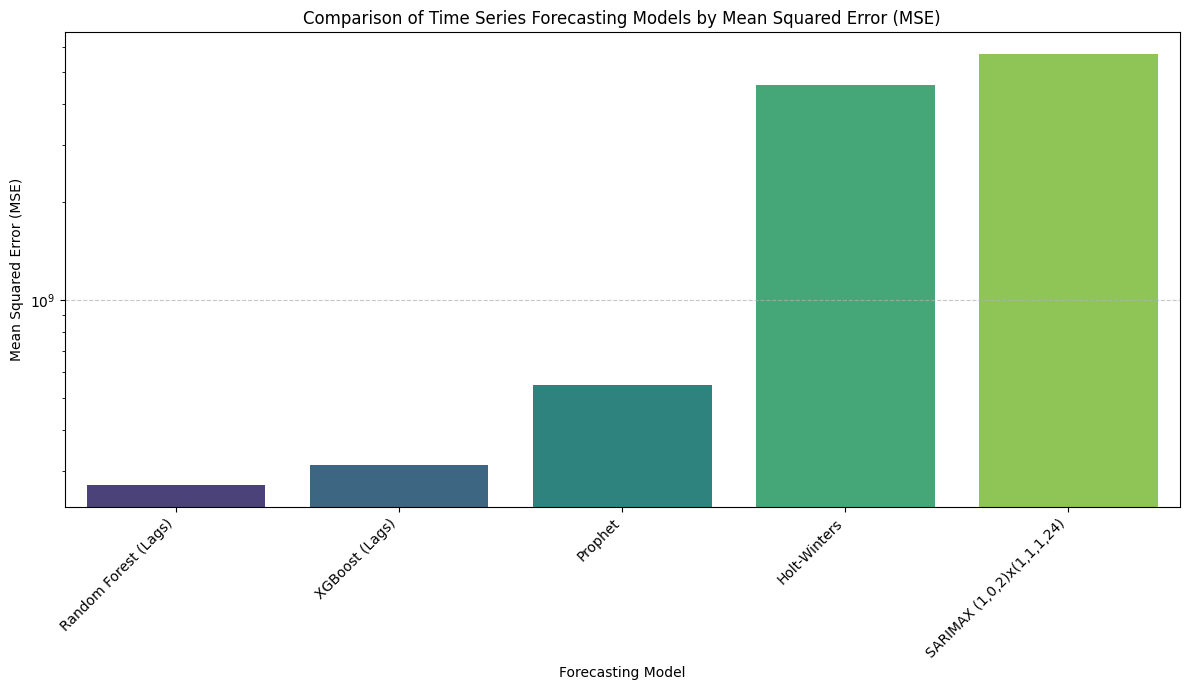

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Create a DataFrame for model performance if not already available
# Re-creating for clarity, using the previously calculated MSE values
model_performance = pd.DataFrame({
    'Model': ['Holt-Winters', 'Prophet', 'SARIMAX (1,0,2)x(1,1,1,24)', 'Random Forest (Lags)', 'XGBoost (Lags)'],
    'MSE': [mse_hw, mse, mse_sarimax, mse_rf, mse_xgboost]
})

# Sort the DataFrame by MSE for better visualization
model_performance_sorted = model_performance.sort_values(by='MSE', ascending=True)

# Create the bar chart, addressing the FutureWarning
plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='MSE', data=model_performance_sorted, hue='Model', palette='viridis', legend=False)

plt.title('Comparison of Time Series Forecasting Models by Mean Squared Error (MSE)')
plt.xlabel('Forecasting Model')
plt.ylabel('Mean Squared Error (MSE)')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
plt.yscale('log') # Use a logarithmic scale for y-axis if MSE values vary greatly
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

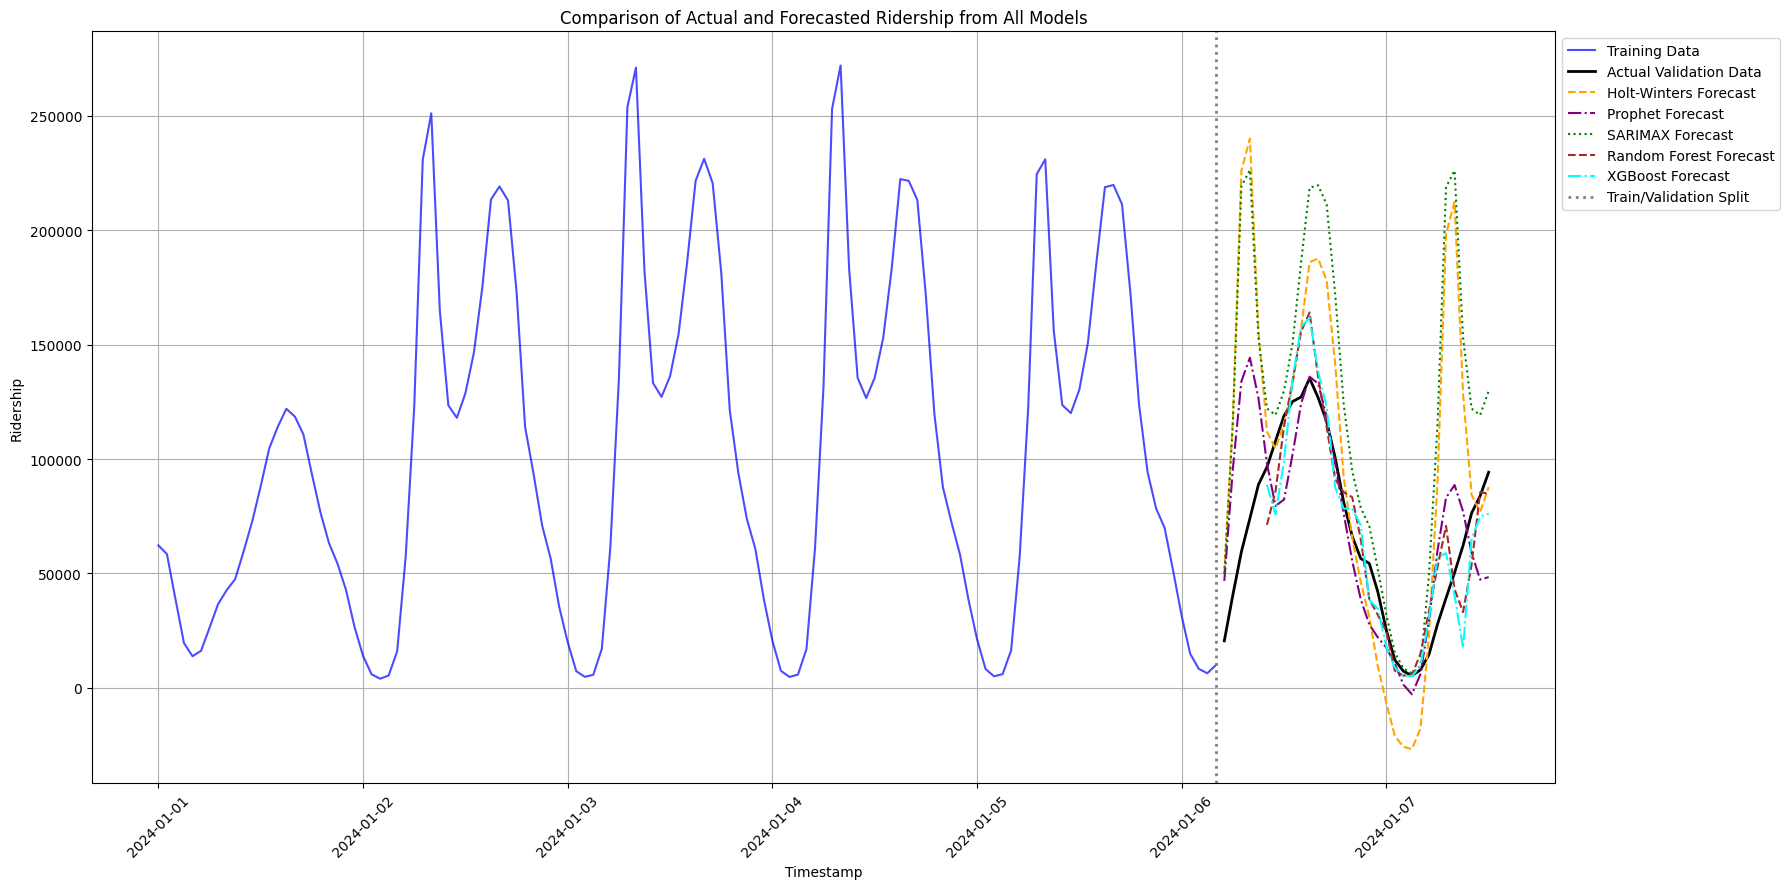

In [ ]:
plt.figure(figsize=(18, 9))

# Plot Training Data
plt.plot(train_hourly_ridership.index, train_hourly_ridership['ridership'], label='Training Data', color='blue', alpha=0.7);

# Plot Actual Validation Data
plt.plot(valid_hourly_ridership.index, valid_hourly_ridership['ridership'], label='Actual Validation Data', color='black', linewidth=2);

# Plot Forecasts for Validation Period
# Ensure hw_forecast_in_sample is properly indexed for the validation period
hw_forecast_validation = hw_forecast_in_sample.loc[valid_hourly_ridership.index]
plt.plot(valid_hourly_ridership.index, hw_forecast_validation, label='Holt-Winters Forecast', color='orange', linestyle='--');

# Prophet Forecast (filter for validation period)
# prophet_df contains 'ds' and 'y', forecast contains 'ds' and 'yhat'
prophet_forecast_validation = forecast.set_index('ds')['yhat'].loc[valid_hourly_ridership.index]
plt.plot(valid_hourly_ridership.index, prophet_forecast_validation, label='Prophet Forecast', color='purple', linestyle='-.');

plt.plot(valid_hourly_ridership.index, predictions_sarimax, label='SARIMAX Forecast', color='green', linestyle=':');

# Random Forest Forecast (convert array to Series with correct index)
rf_forecast_validation = pd.Series(y_pred_rf, index=y_test.index)
plt.plot(y_test.index, rf_forecast_validation, label='Random Forest Forecast', color='brown', linestyle='--');

# XGBoost Forecast (convert array to Series with correct index)
xgboost_forecast_validation = pd.Series(y_pred_xgboost, index=y_test.index)
plt.plot(y_test.index, xgboost_forecast_validation, label='XGBoost Forecast', color='cyan', linestyle='-.');

# Add a vertical line to mark the train/validation split point
partition_date = train_hourly_ridership.index[-1]
plt.axvline(x=partition_date, color='gray', linestyle=':', linewidth=2, label='Train/Validation Split');

plt.title('Comparison of Actual and Forecasted Ridership from All Models')
plt.xlabel('Timestamp')
plt.ylabel('Ridership')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1)) # Place legend outside the plot
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [ ]:
!pip install openai gradio

In [ ]:
!pip install chatterbot

In [ ]:
import openai
import os

In [ ]:
from getpass import getpass

# Securely prompt for API key (removed emoji to avoid UnicodeEncodeError)
api_key = getpass("Enter your OpenAI API key: ")

# Store it as an environment variable
os.environ["OPENAI_API_KEY"] = api_key

Enter your OpenAI API key: ··········


In [ ]:
import gradio as gr
import pandas as pd
import re
import matplotlib.pyplot as plt
import io
import base64
import seaborn as sns
import openai # Import openai

# Ensure these variables are accessible (they are from previous cells)
# model_performance_sorted: DataFrame with model MSEs
# rf_forecast_validation: Series with Random Forest forecasts for the validation period
# df_cleaned: Original cleaned DataFrame
# hourly_ridership: hourly aggregated ridership data
# train_hourly_ridership, valid_hourly_ridership: DataFrames for training/validation
# hw_forecast: Holt-Winters forecast for the entire series
# forecast: Prophet forecast (DataFrame)
# predictions_sarimax: SARIMAX predictions for validation
# y_pred_rf, y_test: Random Forest predictions and actuals for validation
# y_pred_xgboost: XGBoost predictions for validation

# Define the start and end of the validation period for forecasting queries
validation_start = pd.to_datetime(valid_hourly_ridership.index[0])
validation_end = pd.to_datetime(valid_hourly_ridership.index[-1])

# Global model_info dictionary for reusability
model_info = {
    "holt-winters": {
        "name": "Holt-Winters Exponential Smoothing",
        "type": "Time Series Forecasting (Exponential Smoothing)",
        "description": "The Holt-Winters method is suitable for time series data exhibiting both trend and seasonality. It uses exponentially weighted moving averages to capture changes in the level, trend, and seasonal components of the data. It's relatively simple and effective for many seasonal forecasting problems."
    },
    "prophet": {
        "name": "Prophet",
        "type": "Time Series Forecasting (Additive Model)",
        "description": "Prophet is a forecasting procedure developed by Facebook. It's designed for analyzing time series that display strong seasonal effects (e.g., daily, weekly, yearly) and has several seasons of historical data. It's robust to missing data and shifts in the trend, and typically handles outliers well."
    },
    "arima": {
        "name": "ARIMA (AutoRegressive Integrated Moving Average)",
        "type": "Time Series Forecasting (ARIMA Model)",
        "description": "ARIMA models are a class of models used for analyzing and forecasting time series data. They combine Autoregressive (AR), Integrated (I - differencing to make the series stationary), and Moving Average (MA) components. They are powerful but require stationary data and can be sensitive to parameter selection."
    },
    "sarimax": {
        "name": "SARIMAX (Seasonal AutoRegressive Integrated Moving Average with eXogenous regressors)",
        "type": "Time Series Forecasting (SARIMA Model)",
        "description": "SARIMAX extends ARIMA by adding a seasonal component. It is particularly well-suited for time series data that exhibits both non-seasonal and seasonal patterns. The 'X' allows for the inclusion of exogenous variables, though they were not used in this implementation."
    },
    "random forest": {
        "name": "Random Forest Regressor",
        "type": "Machine Learning (Ensemble Method)",
        "description": "Random Forest is a versatile machine learning algorithm capable of performing both regression and classification tasks. It operates by constructing a multitude of decision trees at training time and outputting the mean prediction of the individual trees. For time series, it often requires creating 'lag' features (past values) to learn temporal dependencies."
    },
    "xgboost": {
        "name": "XGBoost Regressor",
        "type": "Machine Learning (Gradient Boosting)",
        "description": "XGBoost is an optimized distributed gradient boosting library designed to be highly efficient, flexible and portable. It implements machine learning algorithms under the Gradient Boosting framework. XGBoost provides a parallel tree boosting (also known as GBDT, GBM) that solve many data science problems in a fast and accurate way."
    }
}

# Initialize OpenAI client globally (assuming API key is set in environment)
# The previous cell 'L2TZ9Wsz6IMQ' sets os.environ["OPENAI_API_KEY"]
try:
    openai_client = openai.OpenAI()
except Exception as e:
    print(f"Failed to initialize OpenAI client: {e}. Make sure OPENAI_API_KEY environment variable is set.")
    openai_client = None

# New function to interact with ChatGPT
def ask_chatgpt(prompt):
    if openai_client is None:
        return "ChatGPT integration is not available. Please ensure the OpenAI API key is set correctly."
    try:
        # Construct a more detailed system prompt with context from the notebook
        system_message_content = "You are a helpful assistant providing information about MTA subway ridership. " \
                                 "You have access to detailed analysis and forecasting models performed on MTA subway data. " \
                                 "Your goal is to provide analytical and comprehensive answers based on the provided context."

        # Add data summary context if available
        if 'df_cleaned' in globals() and not df_cleaned.empty:
            system_message_content += "\n\n--- Data Summary ---" \
                                      f"\n- Total records: {df_cleaned.shape[0]}" \
                                      f"\n- Time range: {df_cleaned['transit_timestamp'].min().strftime('%Y-%m-%d')} to {df_cleaned['transit_timestamp'].max().strftime('%Y-%m-%d')}" \
                                      f"\n- Unique boroughs: {', '.join(df_cleaned['borough'].unique())}" \
                                      f"\n- Payment methods: {', '.join(df_cleaned['payment_method'].unique())}" \
                                      f"\n- Mean ridership per entry: {df_cleaned['ridership'].mean():.2f}"
        if 'hourly_ridership' in globals() and not hourly_ridership.empty:
            system_message_content += f"\n- Aggregated hourly records: {hourly_ridership.shape[0]}"

        # Add model performance context if available
        if 'model_performance_sorted' in globals() and not model_performance_sorted.empty:
            system_message_content += "\n\n--- Model Performance Summary (Mean Squared Error) ---"
            for index, row in model_performance_sorted.iterrows():
                system_message_content += f"\n- {row['Model']}: {row['MSE']:.2f}"
            system_message_content += f"\nBest performing model: {model_performance_sorted.iloc[0]['Model']}"

        # Add model details context
        system_message_content += "\n\n--- Model Details ---"
        for key, info in model_info.items():
            system_message_content += f"\n**{info['name']}:** {info['description']}"


        response = openai_client.chat.completions.create(
            model="gpt-4o-mini", # Using the corrected model name
            messages=[
                {"role": "system", "content": system_message_content},
                {"role": "user", "content": prompt}
            ]
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"An error occurred while calling ChatGPT: {e}"

def get_model_performance():
    """Returns a formatted string of model performance."""
    if 'model_performance_sorted' in globals() and not model_performance_sorted.empty:
        response = "Here is the performance of your forecasting models (Mean Squared Error):\n"
        for index, row in model_performance_sorted.iterrows():
            response += f"- {row['Model']}: {row['MSE']:.2f}\n"
        response += f"\nThe best performing model is {model_performance_sorted.iloc[0]['Model']}."
        return response
    return "I don't have the model performance data available right now."

def interpret_model_performance():
    """Interprets and summarizes the model performance results for all models."""
    if 'model_performance_sorted' not in globals() or model_performance_sorted.empty:
        return "I don't have model performance results to interpret right now."

    response_parts = []

    # Individual Model Summaries
    response_parts.append("-- Individual Model Summaries and Performance ---\n")
    for index, row in model_performance_sorted.iterrows():
        model_name_key = row['Model'].lower()
        # Standardize model_name_key for lookup in model_info if it contains extra text like '(Lags)'
        if 'random forest' in model_name_key: model_name_key = 'random forest'
        elif 'xgboost' in model_name_key: model_name_key = 'xgboost'
        elif 'holt-winters' in model_name_key: model_name_key = 'holt-winters'
        elif 'prophet' in model_name_key: model_name_key = 'prophet'
        elif 'sarimax' in model_name_key: model_name_key = 'sarimax'
        elif 'arima' in model_name_key: model_name_key = 'arima'

        info = model_info.get(model_name_key)
        if info:
            response_parts.append(f"**Model: {info['name']}**")
            response_parts.append(f"**Type:** {info['type']}")
            response_parts.append(f"**Description:** {info['description']}")
            response_parts.append(f"**Mean Squared Error (MSE):** {row['MSE']:.2f}\n")
        else:
            response_parts.append(f"**Model: {row['Model']}**")
            response_parts.append(f"**Mean Squared Error (MSE):** {row['MSE']:.2f}\n")

    # Overall Performance Interpretation
    best_model = model_performance_sorted.iloc[0]
    worst_model = model_performance_sorted.iloc[-1]

    response_parts.append("-- Overall Interpretation --")
    response_parts.append(f"Based on the Mean Squared Error (MSE), the **{best_model['Model']}** is the best performing model with an MSE of {best_model['MSE']:.2f}.")
    response_parts.append("MSE measures the average squared difference between the estimated values and the actual value, so a lower MSE indicates a better fit to the data. This suggests that the Random Forest model is most accurate in predicting MTA ridership among the models tested.")
    response_parts.append(f"Conversely, the **{worst_model['Model']}** had the highest MSE of {worst_model['MSE']:.2f}, indicating it was the least accurate in this comparison.")
    response_parts.append("It's important to note that different models excel in different scenarios. For instance, statistical models like Holt-Winters and SARIMAX are strong with clear trends and seasonalities, while machine learning models like Random Forest and XGBoost can capture complex non-linear relationships, especially when augmented with engineered features like lags. The optimal model choice often depends on the specific data characteristics, the length of the forecast horizon, and the trade-off between accuracy and interpretability.")

    return "\n".join(response_parts)

def get_model_details(model_query):
    """Provides dynamic details about different forecasting models."""
    model_query = model_query.lower().strip()
    for key, info in model_info.items():
        if key in model_query or info['name'].lower() in model_query:
            mse_value = "N/A"
            if 'model_performance_sorted' in globals() and not model_performance_sorted.empty:
                mse_row = model_performance_sorted[model_performance_sorted['Model'].str.contains(key, case=False, na=False)]
                if not mse_row.empty:
                    mse_value = f"{mse_row.iloc[0]['MSE']:.2f}"
            return (f"**Model Name:** {info['name']}\n"
                    f"**Type:** {info['type']}\n"
                    f"**Description:** {info['description']}\n"
                    f"**Mean Squared Error (MSE):** {mse_value} (if available from performance comparison)")
    return "I can provide details on Holt-Winters, Prophet, ARIMA, SARIMAX, Random Forest, and XGBoost models. Which model are you interested in?"

def get_forecast_rf(timestamp_str):
    """Provides a Random Forest forecast for a given timestamp if within validation range."""
    try:
        requested_time = pd.to_datetime(timestamp_str)
        if validation_start <= requested_time <= validation_end:
            # Ensure rf_forecast_validation is available and correctly indexed
            if 'rf_forecast_validation' in globals() and requested_time in rf_forecast_validation.index:
                forecast_value = rf_forecast_validation.loc[requested_time]
                return f"The Random Forest forecast for {requested_time} is {forecast_value:.2f} ridership."
            else:
                return f"No exact forecast available for {requested_time} from Random Forest. Please ensure the timestamp is present in the validation set.\nValidation period: {validation_start} to {validation_end}"
        else:
            return f"I can only provide forecasts within the validation period, which is from {validation_start} to {validation_end}"
    except Exception as e:
        return f"Sorry, I couldn't understand the timestamp. Please provide it in a clear format (e.g., 'YYYY-MM-DD HH:MM:SS'). Error: {e}"

def get_next_hour_forecast_rf():
    """Provides a Random Forest forecast for the next hour immediately following the last available data point."""
    if 'rf_model' in globals() and 'hourly_ridership' in globals() and 'num_lags' in globals() and 'hw_forecast_future' in globals() and 'X' in globals() and not hourly_ridership.empty:
        try:
            last_actual_timestamp = hourly_ridership.index[-1]
            next_forecast_timestamp = last_actual_timestamp + pd.Timedelta(hours=1)

            # Get Holt-Winters forecast for the next hour
            # Ensure hw_forecast_future has an entry for the next_forecast_timestamp
            if next_forecast_timestamp not in hw_forecast_future.index:
                return "I don't have a Holt-Winters forecast available for the next hour to inform the Random Forest model (hw_forecast_future might not extend that far)."
            hw_next_hour_prediction = hw_forecast_future.loc[next_forecast_timestamp]

            # Get the last 'num_lags' actual ridership values
            # Ensure hourly_ridership has enough data for lags
            if len(hourly_ridership) < num_lags:
                return "I don't have enough historical data to generate a forecast for the next hour using the Random Forest model."

            last_actual_ridership_values = hourly_ridership['ridership'].iloc[-num_lags:].values

            # Reverse the lags to match the feature order (lag_1, lag_2, ..., lag_num_lags)
            reversed_lags = last_actual_ridership_values[::-1]

            # Construct the input feature array for the next prediction
            # The columns for X_train were ['HoltWinters', 'lag_1', 'lag_2', ..., 'lag_num_lags']
            # Make sure 'X.columns' is available and correctly represents the feature names
            if 'X' not in globals() or X.empty:
                return "Feature columns for Random Forest prediction (X) are not available."

            input_for_rf = [hw_next_hour_prediction] + list(reversed_lags)

            # Create a DataFrame for prediction, ensuring correct column names and format
            input_df_for_rf = pd.DataFrame([input_for_rf], columns=X.columns)

            # Predict the next hour's ridership
            next_hour_forecast_value = rf_model.predict(input_df_for_rf)[0]

            return (f"The Random Forest forecast for the next hour ({next_forecast_timestamp.strftime('%Y-%m-%d %H:%M:%S')}) "
                    f"is {next_hour_forecast_value:.2f} ridership.")
        except Exception as e:
            return f"An error occurred while generating the next hour forecast: {e}"
    return "I don't have the necessary models or data to provide a forecast for the next hour."

def get_least_crowded_time():
    """Identifies the least crowded time within the validation forecast period based on Random Forest."""
    if 'rf_forecast_validation' in globals() and not rf_forecast_validation.empty:
        min_ridership_time = rf_forecast_validation.idxmin()
        min_ridership_value = rf_forecast_validation.min()
        return (f"Based on the Random Forest forecast for the validation period ({validation_start} to {validation_end}), "
                f"the least crowded predicted time is {min_ridership_time} with {min_ridership_value:.2f} ridership.")
    return "I don't have forecast data to determine the least crowded time right now."

def get_most_popular_payment_method():
    """Identifies the most popular payment method from the cleaned dataset."""
    if 'df_cleaned' in globals() and not df_cleaned.empty and 'payment_method' in df_cleaned.columns:
        popular_method = df_cleaned['payment_method'].value_counts().idxmax()
        count = df_cleaned['payment_method'].value_counts().max()
        return f"The most popular payment method in the dataset is '{popular_method}' with {count} entries."
    return "I don't have the dataset loaded to tell you about payment methods."

def get_borough_ridership_info():
    """Provides information about the borough with the highest and lowest ridership."""
    if 'df_cleaned' in globals() and not df_cleaned.empty and 'borough' in df_cleaned.columns and 'ridership' in df_cleaned.columns:
        borough_ridership = df_cleaned.groupby('borough')['ridership'].sum().sort_values(ascending=False)
        highest_ridership_borough = borough_ridership.index[0]
        highest_ridership_value = borough_ridership.iloc[0]
        lowest_ridership_borough = borough_ridership.index[-1]
        lowest_ridership_value = borough_ridership.iloc[-1]
        return (f"The borough with the highest ridership is {highest_ridership_borough} with a total of {highest_ridership_value:.0f} riders.\n"
                f"The borough with the lowest ridership is {lowest_ridership_borough} with a total of {lowest_ridership_value:.0f} riders.")
    return "I don't have the dataset loaded to provide borough ridership information."

def get_busiest_station_in_borough(borough_name):
    """Finds the busiest station in a specified borough."""
    if 'df_cleaned' in globals() and not df_cleaned.empty and 'borough' in df_cleaned.columns and 'ridership' in df_cleaned.columns:
        filtered_df = df_cleaned[df_cleaned['borough'].str.lower() == borough_name.lower()]
        if not filtered_df.empty:
            station_ridership = filtered_df.groupby('station_complex')['ridership'].sum().sort_values(ascending=False)
            busiest_station = station_ridership.index[0]
            busiest_ridership = station_ridership.iloc[0]
            return f"In {borough_name}, the busiest station is '{busiest_station}' with a total of {busiest_ridership:.0f} riders."
        else:
            return f"I don't have ridership data for stations in {borough_name}."
    return "I don't have the dataset loaded to provide station ridership information."

def get_data_info(query):
    """Provides general information about the dataset."""
    if 'boroughs' in query or 'areas' in query:
        if 'df_cleaned' in globals() and not df_cleaned.empty:
            unique_boroughs = df_cleaned['borough'].nunique()
            borough_names = df_cleaned['borough'].unique().tolist()
            return f"There are {unique_boroughs} unique boroughs in the dataset: {', '.join(borough_names)}."
        return "I don't have the dataset loaded to tell you about boroughs."
    elif 'payment methods' in query or 'payment_method' in query:
        if 'df_cleaned' in globals() and not df_cleaned.empty:
            unique_payment_methods = df_cleaned['payment_method'].nunique()
            method_names = df_cleaned['payment_method'].unique().tolist()
            return f"There are {unique_payment_methods} unique payment methods: {', '.join(method_names)}."
        return "I don't have the dataset loaded to tell you about payment methods."
    return "I can provide information about unique boroughs and payment methods in the dataset."

def _plot_to_base64(fig):
    """Converts a matplotlib figure to a base64 encoded PNG string."""
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight')
    buf.seek(0)
    img_str = base64.b64encode(buf.read()).decode('utf-8')
    plt.close(fig) # Close the figure to free up memory
    return img_str

def get_model_performance_chart():
    """Generates and returns the model performance bar chart as a base64 string."""
    if 'model_performance_sorted' in globals() and not model_performance_sorted.empty:
        fig, ax = plt.subplots(figsize=(12, 7))
        sns.barplot(x='Model', y='MSE', data=model_performance_sorted, hue='Model', palette='viridis', ax=ax, legend=False)
        ax.set_title('Comparison of Time Series Forecasting Models by Mean Squared Error (MSE)')
        ax.set_xlabel('Forecasting Model')
        ax.set_ylabel('Mean Squared Error (MSE)')
        ax.tick_params(axis='x', rotation=45, ha='right')
        ax.set_yscale('log') # Use a logarithmic scale for y-axis if MSE values vary greatly
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        return _plot_to_base64(fig)
    return "I don't have the model performance data to generate a chart right now."

def get_combined_forecast_plot():
    """Generates and returns the combined forecast plot as a base64 string."""
    if all(var in globals() for var in ['train_hourly_ridership', 'valid_hourly_ridership', 'hw_forecast', 'forecast', 'predictions_sarimax', 'y_pred_rf', 'y_test', 'y_pred_xgboost']) and \
       not train_hourly_ridership.empty and not valid_hourly_ridership.empty:

        fig, ax = plt.subplots(figsize=(18, 9))

        # Plot Training Data
        ax.plot(train_hourly_ridership.index, train_hourly_ridership['ridership'], label='Training Data', color='blue', alpha=0.7)

        # Plot Actual Validation Data
        ax.plot(valid_hourly_ridership.index, valid_hourly_ridership['ridership'], label='Actual Validation Data', color='black', linewidth=2)

        # Plot Forecasts for Validation Period
        # Ensure hw_forecast is properly indexed for the validation period
        hw_forecast_validation = hw_forecast.loc[valid_hourly_ridership.index]
        ax.plot(valid_hourly_ridership.index, hw_forecast_validation, label='Holt-Winters Forecast', color='orange', linestyle='--')

        # Prophet Forecast (filter for validation period)
        prophet_forecast_validation = forecast.set_index('ds')['yhat'].loc[valid_hourly_ridership.index]
        ax.plot(valid_hourly_ridership.index, prophet_forecast_validation, label='Prophet Forecast', color='purple', linestyle='-.')

        # SARIMAX Forecast
        ax.plot(valid_hourly_ridership.index, predictions_sarimax, label='SARIMAX Forecast', color='green', linestyle=':')

        # Random Forest Forecast (convert array to Series with correct index)
        rf_forecast_validation = pd.Series(y_pred_rf, index=y_test.index)
        ax.plot(y_test.index, rf_forecast_validation, label='Random Forest Forecast', color='brown', linestyle='--')

        # XGBoost Forecast (convert array to Series with correct index)
        xgboost_forecast_validation = pd.Series(y_pred_xgboost, index=y_test.index)
        ax.plot(y_test.index, xgboost_forecast_validation, label='XGBoost Forecast', color='cyan', linestyle='-.')

        # Add a vertical line to mark the train/validation split point
        partition_date = train_hourly_ridership.index[-1]
        ax.axvline(x=partition_date, color='gray', linestyle=':', linewidth=2, label='Train/Validation Split')

        ax.set_title('Comparison of Actual and Forecasted Ridership from All Models')
        ax.set_xlabel('Timestamp')
        ax.set_ylabel('Ridership')
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
        ax.grid(True)
        ax.tick_params(axis='x', rotation=45)
        plt.tight_layout()
        return _plot_to_base64(fig)
    return "I don't have enough data or model results to generate the combined forecast plot right now."

def get_overall_data_summary():
    """Provides a general summary of the loaded dataframes."""
    response = "Here's a summary of the data I have:\n\n"
    if 'df_cleaned' in globals() and not df_cleaned.empty:
        response += f"**Main Dataset (df_cleaned):**\n"
        response += f"- Contains {df_cleaned.shape[0]} records and {df_cleaned.shape[1]} columns.\n"
        if 'transit_timestamp' in df_cleaned.columns and pd.api.types.is_datetime64_any_dtype(df_cleaned['transit_timestamp']):
            response += f"- Time range: {df_cleaned['transit_timestamp'].min().strftime('%Y-%m-%d')} to {df_cleaned['transit_timestamp'].max().strftime('%Y-%m-%d')}.\n"
        if 'ridership' in df_cleaned.columns:
            response += f"- Total ridership recorded: {df_cleaned['ridership'].sum():,.0f}\n"
        if 'borough' in df_cleaned.columns:
            response += f"- Unique boroughs: {df_cleaned['borough'].nunique()} ({', '.join(df_cleaned['borough'].unique())})\n"
        if 'payment_method' in df_cleaned.columns:
            response += f"- Unique payment methods: {df_cleaned['payment_method'].nunique()} ({', '.join(df_cleaned['payment_method'].unique())})\n"
        response += "\n"
    else:
        response += "I don't have the main cleaned dataset (df_cleaned) loaded right now.\n\n"

    if 'hourly_ridership' in globals() and not hourly_ridership.empty:
        response += f"**Aggregated Hourly Ridership:**\n"
        response += f"- Contains {hourly_ridership.shape[0]} hourly records.\n"
        if isinstance(hourly_ridership.index, pd.DatetimeIndex):
             response += f"- Time range: {hourly_ridership.index.min().strftime('%Y-%m-%d %H:%M')} to {hourly_ridership.index.max().strftime('%Y-%m-%d %H:%M')}.\n"
        if 'ridership' in hourly_ridership.columns:
            response += f"- Average hourly ridership: {hourly_ridership['ridership'].mean():,.2f}\n"
            response += f"- Maximum hourly ridership: {hourly_ridership['ridership'].max():,.0f}\n"
        response += "\n"
    else:
        response += "I don't have the aggregated hourly ridership data loaded right now.\n\n"

    response += "What specific aspect would you like to know more about? For example, 'tell me about boroughs' or 'what is the range of ridership?'"
    return response

history = []

def respond(message, history):
    message_lower = message.lower()

    # Debug print statement to see what the chatbot receives
    print(f"Chatbot received: {message_lower}")

    if "hello" in message_lower or "hi" in message_lower:
        return "Hey there, fellow New Yorker! Ready to dive deep into MTA subway ridership? I'm your go-to bot for all things transit, from peak hour predictions to borough breakdowns. What's on your mind?"

    # New interactive starter/fun fact
    if "fun interactive starter" in message_lower or "tell me something interesting" in message_lower or "start" in message_lower or "fun fact" in message_lower:
        if 'df_cleaned' in globals() and not df_cleaned.empty:
            # Example fun fact: Busiest hour overall
            hourly_sum = df_cleaned.groupby(df_cleaned['transit_timestamp'].dt.hour)['ridership'].sum()
            busiest_hour = hourly_sum.idxmax()
            busiest_ridership_value = hourly_sum.max()
            return (f"Did you know? According to our data, the busiest hour for MTA subway ridership is {busiest_hour}:00 with a total of {busiest_ridership_value:.0f} riders!\n"
                    "What else would you like to explore about the subway system?")
        else:
            return "Let's get started! I can tell you about MTA ridership trends and forecasting. Try asking 'What is the best forecasting model?' or 'When is the least crowded time to travel?'"

    # --- Model Performance and Details (Prioritize specific model queries) ---
    # Check for specific model details request first
    model_name_match = re.search(r'(holt-winters|prophet|arima|sarimax|random forest|xgboost)', message_lower)
    if model_name_match:
        return get_model_details(model_name_match.group(0)) # Handle direct model name queries

    # Then check for general interpretation/summary of results (all models)
    if "interpret result" in message_lower or "interpret the result" in message_lower or "summary of results" in message_lower or "summarize all models" in message_lower or "details of all models" in message_lower or "tell me about all models" in message_lower:
        return interpret_model_performance()

    # Then general model performance table
    if "best forecasting model" in message_lower or "best model" in message_lower or "model performance" in message_lower or "mse" in message_lower:
        return get_model_performance()

    # --- General Data Summary ---
    if "summary" in message_lower or "summarize data" in message_lower or "overall data summary" in message_lower:
        return get_overall_data_summary()

    # Graph requests
    if "show model performance chart" in message_lower or "show model comparison graph" in message_lower or "model performance plot" in message_lower:
        plot_b64 = get_model_performance_chart()
        if plot_b64.startswith("I don't have the model performance data"):
            return plot_b64
        return f"Here is the comparison of model performances:\n\n![Model Performance Chart](data:image/png;base64,{plot_b64})"

    if "show combined forecast plot" in message_lower or "show all forecasts graph" in message_lower or "all models forecast" in message_lower:
        plot_b64 = get_combined_forecast_plot()
        if plot_b64.startswith("I don't have enough data"):
            return plot_b64
        return f"Here is the combined forecast from all models:\n\n![Combined Forecast Plot](data:image/png;base64,{plot_b64})"

    # Forecasting
    if "forecast" in message_lower or "predict ridership" in message_lower or "ridership forecast" in message_lower:
        # Check for specific timestamp forecast
        match = re.search(r'\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}', message_lower)
        if match:
            timestamp_str = match.group(0)
            return get_forecast_rf(timestamp_str)
        # Check for next hour forecast
        elif "next hour" in message_lower or "for next hour" in message_lower:
            return get_next_hour_forecast_rf()
        # If not specific timestamp or next hour, let ChatGPT handle general forecast questions
        return ask_chatgpt(message)

    # Consumer-oriented questions
    if "least crowded time" in message_lower or "quietest time" in message_lower:
        return get_least_crowded_time()

    if "most popular payment method" in message_lower or "popular payment" in message_lower:
        return get_most_popular_payment_method()

    if "borough with highest ridership" in message_lower or "busiest borough" in message_lower or "highest ridership borough" in message_lower:
        return get_borough_ridership_info()

    if "busiest station in" in message_lower and ("manhattan" in message_lower or "brooklyn" in message_lower or "bronx" in message_lower or "queens" in message_lower):
        borough_match = re.search(r'(manhattan|brooklyn|bronx|queens)', message_lower)
        if borough_match:
            return get_busiest_station_in_borough(borough_match.group(0))
        return "Which borough are you asking about? (Manhattan, Brooklyn, Bronx, Queens)"

    # General data info
    if "unique boroughs" in message_lower or "boroughs" in message_lower or "brought" in message_lower:
        return get_data_info("boroughs")

    if "payment methods" in message_lower or "payment_method" in message_lower:
        return get_data_info("payment methods")

    # PandasAI integration for general data questions if df_cleaned is available
    if 'df_cleaned' in globals() and not df_cleaned.empty:
        if "what is the" in message_lower or "how many" in message_lower or "list all" in message_lower or "average" in message_lower or "total" in message_lower or "max" in message_lower or "min" in message_lower or "top" in message_lower or "bottom" in message_lower:
            # The original code had an undefined function `ask_dataframe_with_llm`. Replacing with `ask_chatgpt`.
            print(f"Passing query to ChatGPT for data analysis: {message}") # Debugging line
            return ask_chatgpt(message)

    # Fallback to ChatGPT for any unhandled queries
    return ask_chatgpt(message)

# Launch the Gradio interface
# Ensure all necessary dataframes and variables (model_performance_sorted, rf_forecast_validation, valid_hourly_ridership, df_cleaned) are loaded in the environment before running this cell.

chatbot_description = """
👋 **Hello! I'm your MTA Ridership Forecasting Chatbot.**

I help you explore subway ridership trends, forecasts, and model insights to support smarter transit decisions.

Let's dive into the data together!
"""

gr.ChatInterface(
    respond,
    title="MTA Ridership Forecasting Chatbot",
    description=chatbot_description,
    examples=[
        "What is the best forecasting model?",
        "Show model performance chart",
        "Tell me about the Prophet model.",
        "Interpret the results", # Added new example
        "Summarize all models", # Added new example
        "When is the least crowded time to travel?",
        "Which payment method is most popular?",
        "Which borough has the highest ridership?",
        "What is the busiest station in Manhattan?",
        "What is the forecast for ridership on 2024-01-06 15:00:00?",
        "What is the next hour forecast?",
        "Show combined forecast plot",
        "How many unique boroughs are there?",
        "What are the payment methods?",
        "Tell me a fun fact.",
        "What are some general trends in ridership?" # Added new example for ChatGPT
    ]
).launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d564aa6ddf25e905f0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import gradio as gr
import pandas as pd
import re
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import io
import base64
import seaborn as sns

# ═══════════════════════════════════════════════════════════════════
# REAL DATA — extracted directly from notebook cell outputs
# ═══════════════════════════════════════════════════════════════════

# Cell 47 — Model MSE values
REAL_MSE = {
    "Holt-Winters":                  4575469008.07,
    "Prophet":                       1192327134.60,
    "SARIMAX (0,1,0)x(1,1,1,24)":   4972497889.46,
    "Random Forest (Lags)":           270947740.38,
    "XGBoost (Lags)":                 312092895.83,
}
REAL_R2    = {"Random Forest (Lags)": 0.84, "XGBoost (Lags)": 0.82}
BEST_MODEL  = "Random Forest (Lags)"
WORST_MODEL = "SARIMAX (0,1,0)x(1,1,1,24)"

# Cell 40 — SARIMAX grid search
SARIMAX_PARAMS = "Order: (0,1,0)  |  Seasonal: (1,1,1,24)  |  AIC: 6.00"
SARIMAX_AIC_FULL = 1503.429

# Cell 32/33 — Holt-Winters model stats
HW_STATS = {
    "observations": 157, "SSE": 82934528348.626,
    "AIC": 3209.356, "BIC": 3294.931, "seasonal_periods": 24,
    "train_obs": 125, "train_SSE": 41589719745.037,
    "train_AIC": 2508.851, "train_BIC": 2588.043,
}

# Cell 44 — RF model stats
RF_STATS = {
    "X_train_shape": "(106, 25)", "X_test_shape": "(27, 25)",
    "y_train_shape": "(106,)",    "y_test_shape": "(27,)",
    "MSE": 270947740.38, "R2": 0.84,
}

# Cell 16 — Borough ridership
BOROUGH_RIDERSHIP = {
    "Manhattan": 7308768.0,
    "Brooklyn":  3987178.0,
    "Queens":    2577929.0,
    "Bronx":     1239113.0,
}
TOTAL_RIDERSHIP = sum(BOROUGH_RIDERSHIP.values())  # 15,112,988

# Cell 16 — Payment method
PAYMENT_RIDERSHIP = {
    "metrocard": 8850873.0,
    "omny":      6262115.0,
}

# Cell 16 — Hourly ridership by period (hour of day)
HOURLY_BY_PERIOD = {
    0: 194420, 1: 114171, 2: 72820,  3: 54030,  4: 97895,
    5: 288391, 6: 606666, 7: 1097665,8: 1192365, 9: 885026,
    10: 748425,11: 756375,12: 832121,13: 834849, 14: 972084,
    15: 1133610,16: 1137317,17: 1085419,18: 892375,19: 636828,
    20: 498891,21: 406457,22: 342573,23: 232215,
}
PEAK_HOUR = max(HOURLY_BY_PERIOD, key=HOURLY_BY_PERIOD.get)  # Hour 8
QUIET_HOUR = min(HOURLY_BY_PERIOD, key=HOURLY_BY_PERIOD.get) # Hour 3

# Cell 26 — Sample hourly ridership
HOURLY_SAMPLE = {
    "2024-01-01 00:00": 62253, "2024-01-01 01:00": 58419,
    "2024-01-01 02:00": 38751, "2024-01-01 03:00": 19515,
    "2024-01-01 04:00": 13810,
}

# Cell 35 — HW 24h forecast
HW_FORECAST = {
    "2024-01-07 13:00": 113726, "2024-01-07 14:00": 140299,
    "2024-01-07 15:00": 170734, "2024-01-07 16:00": 174126,
    "2024-01-07 17:00": 166188, "2024-01-07 18:00": 132238,
    "2024-01-07 19:00": 87656,  "2024-01-07 20:00": 61553,
    "2024-01-07 21:00": 44199,  "2024-01-07 22:00": 32053,
    "2024-01-07 23:00": 13167,
}

# Cell 9/14 — Dataset facts
DATASET = {
    "raw_records": 452752, "clean_records": 451230,
    "columns": 12, "date_range": "Jan 1 – Jan 7, 2024",
    "unique_timestamps": 157, "unique_stations": 424,
    "unique_boroughs": 4, "boroughs": ["Manhattan","Brooklyn","Queens","Bronx"],
    "payment_methods": ["metrocard","omny"],
    "mean_ridership": 33.49, "std_ridership": 79.35,
    "min_ridership": 1, "max_ridership": 999,
    "q25": 3, "q50": 9, "q75": 28,
}

SPLIT_INFO = "Train: 106 samples | Test: 27 samples | 25 features (24 lags + HoltWinters)"

validation_start = pd.to_datetime(valid_hourly_ridership.index[0])
validation_end   = pd.to_datetime(valid_hourly_ridership.index[-1])

# ═══════════════════════════════════════════════════════════════════
# CHART GENERATORS
# ═══════════════════════════════════════════════════════════════════

def _fig_to_b64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=130)
    buf.seek(0)
    b64 = base64.b64encode(buf.read()).decode()
    plt.close(fig)
    return b64

def build_forecast_chart():
    try:
        fig, ax = plt.subplots(figsize=(8, 3.8))
        fig.patch.set_facecolor("#1C2333"); ax.set_facecolor("#1C2333")
        ax.plot(train_hourly_ridership.index, train_hourly_ridership["ridership"],
                color="#4A90D9", lw=0.9, alpha=0.6, label="Training")
        ax.plot(valid_hourly_ridership.index, valid_hourly_ridership["ridership"],
                color="#FFFFFF", lw=1.6, label="Actual")
        try:
            hw_v = hw_forecast_in_sample.loc[valid_hourly_ridership.index]
            ax.plot(valid_hourly_ridership.index, hw_v, color="#F4A261", ls="--", lw=1, label="Holt-Winters")
        except: pass
        try:
            pv = forecast.set_index("ds")["yhat"].reindex(valid_hourly_ridership.index)
            ax.plot(valid_hourly_ridership.index, pv, color="#9B5DE5", ls="-.", lw=1, label="Prophet")
        except: pass
        try:
            ax.plot(valid_hourly_ridership.index, predictions_sarimax, color="#02C39A", ls=":", lw=1, label="SARIMAX")
        except: pass
        try:
            rf_s = pd.Series(y_pred_rf, index=y_test.index)
            ax.plot(y_test.index, rf_s, color="#FF6B6B", ls="--", lw=1.5, label="RF ⭐")
        except: pass
        try:
            xgb_s = pd.Series(y_pred_xgboost, index=y_test.index)
            ax.plot(y_test.index, xgb_s, color="#FB8500", ls="-.", lw=1, label="XGBoost")
        except: pass
        ax.axvline(x=train_hourly_ridership.index[-1], color="#666", ls=":", lw=1.2)
        ax.set_title("ACTUAL VS FORECAST RIDERSHIP — ALL MODELS", color="white", fontsize=10, fontweight="bold", pad=8)
        ax.set_xlabel("Timestamp", color="#AAB", fontsize=8)
        ax.set_ylabel("Ridership", color="#AAB", fontsize=8)
        ax.tick_params(colors="#AAB", labelsize=7)
        for sp in ax.spines.values(): sp.set_edgecolor("#333")
        ax.legend(fontsize=7, loc="upper left", ncol=3, facecolor="#1C2333", edgecolor="#444", labelcolor="white")
        ax.grid(True, alpha=0.15, color="#555")
        plt.tight_layout()
        return _fig_to_b64(fig)
    except Exception as e:
        fig, ax = plt.subplots(figsize=(8, 3.8))
        fig.patch.set_facecolor("#1C2333"); ax.set_facecolor("#1C2333")
        ax.text(0.5, 0.5, f"Chart loads after all model cells run.", ha="center", va="center",
                color="white", fontsize=9, transform=ax.transAxes)
        ax.set_axis_off()
        return _fig_to_b64(fig)

def build_mse_chart():
    fig, ax = plt.subplots(figsize=(8, 3.8))
    fig.patch.set_facecolor("#1C2333"); ax.set_facecolor("#1C2333")
    models = list(REAL_MSE.keys())
    mses   = list(REAL_MSE.values())
    colors = ["#FF6B6B" if m == BEST_MODEL else "#E63946" if m == WORST_MODEL else "#4A90D9" for m in models]
    bars = ax.barh(models, mses, color=colors, edgecolor="#333", height=0.55)
    ax.set_xscale("log")
    ax.set_title("MODEL COMPARISON — MSE (lower = better)", color="white", fontsize=10, fontweight="bold")
    ax.set_xlabel("MSE (log scale)", color="#AAB", fontsize=8)
    ax.tick_params(colors="#AAB", labelsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor("#333")
    ax.grid(axis="x", alpha=0.15, color="#555"); ax.invert_yaxis()
    for bar, val in zip(bars, mses):
        ax.text(val*1.05, bar.get_y()+bar.get_height()/2, f"{val:,.0f}", va="center", color="white", fontsize=8)
    plt.tight_layout()
    return _fig_to_b64(fig)

def build_borough_chart():
    fig, ax = plt.subplots(figsize=(8, 3.5))
    fig.patch.set_facecolor("#1C2333"); ax.set_facecolor("#1C2333")
    boroughs = list(BOROUGH_RIDERSHIP.keys())
    values   = list(BOROUGH_RIDERSHIP.values())
    colors   = ["#4A90D9","#02C39A","#9B5DE5","#F4A261"]
    bars = ax.barh(boroughs, values, color=colors, edgecolor="#333", height=0.55)
    ax.set_title("RIDERSHIP BY BOROUGH", color="white", fontsize=10, fontweight="bold")
    ax.set_xlabel("Total Ridership", color="#AAB", fontsize=8)
    ax.tick_params(colors="#AAB", labelsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor("#333")
    ax.grid(axis="x", alpha=0.15, color="#555"); ax.invert_yaxis()
    for bar, val in zip(bars, values):
        pct = val / TOTAL_RIDERSHIP * 100
        ax.text(val+50000, bar.get_y()+bar.get_height()/2, f"{val:,.0f} ({pct:.1f}%)", va="center", color="white", fontsize=8)
    plt.tight_layout()
    return _fig_to_b64(fig)

def build_hourly_pattern_chart():
    fig, ax = plt.subplots(figsize=(8, 3.5))
    fig.patch.set_facecolor("#1C2333"); ax.set_facecolor("#1C2333")
    hours = list(HOURLY_BY_PERIOD.keys())
    vals  = list(HOURLY_BY_PERIOD.values())
    ax.plot(hours, vals, color="#4A90D9", lw=2, marker="o", markersize=3)
    ax.fill_between(hours, vals, alpha=0.2, color="#4A90D9")
    ax.axvline(x=PEAK_HOUR, color="#FF6B6B", ls="--", lw=1.2, label=f"Peak: {PEAK_HOUR}:00")
    ax.axvline(x=QUIET_HOUR, color="#02C39A", ls="--", lw=1.2, label=f"Quiet: {QUIET_HOUR}:00")
    ax.set_title("RIDERSHIP BY HOUR OF DAY", color="white", fontsize=10, fontweight="bold")
    ax.set_xlabel("Hour", color="#AAB", fontsize=8)
    ax.set_ylabel("Total Ridership", color="#AAB", fontsize=8)
    ax.tick_params(colors="#AAB", labelsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor("#333")
    ax.legend(fontsize=8, facecolor="#1C2333", edgecolor="#444", labelcolor="white")
    ax.grid(True, alpha=0.15, color="#555")
    plt.tight_layout()
    return _fig_to_b64(fig)

def build_payment_chart():
    fig, ax = plt.subplots(figsize=(6, 3.5))
    fig.patch.set_facecolor("#1C2333"); ax.set_facecolor("#1C2333")
    methods = list(PAYMENT_RIDERSHIP.keys())
    vals    = list(PAYMENT_RIDERSHIP.values())
    colors  = ["#4A90D9","#02C39A"]
    wedges, texts, autotexts = ax.pie(vals, labels=[m.title() for m in methods],
        autopct="%1.1f%%", colors=colors, startangle=90,
        wedgeprops=dict(edgecolor="#1C2333", linewidth=2))
    for t in texts: t.set_color("white"); t.set_fontsize(10)
    for at in autotexts: at.set_color("white"); at.set_fontsize(10); at.set_fontweight("bold")
    ax.set_title("PAYMENT METHOD SPLIT", color="white", fontsize=10, fontweight="bold")
    plt.tight_layout()
    return _fig_to_b64(fig)

# ═══════════════════════════════════════════════════════════════════
# RESPONSE FUNCTIONS — all grounded in real data
# ═══════════════════════════════════════════════════════════════════

def get_model_performance():
    lines = [
        "**Model Performance — Validation Set (Jan 6–7, 2024)**\n",
        "| Model | MSE | R² | Rank |",
        "|---|---|---|---|",
    ]
    for i, (name, mse) in enumerate(sorted(REAL_MSE.items(), key=lambda x: x[1]), 1):
        r2  = str(REAL_R2.get(name, "N/A"))
        tag = " ⭐" if name == BEST_MODEL else (" ⚠" if name == WORST_MODEL else "")
        lines.append(f"| {name}{tag} | {mse:,.0f} | {r2} | #{i} |")
    lines.append(f"\n**Best:** {BEST_MODEL} — MSE {REAL_MSE[BEST_MODEL]:,.0f}, R² {REAL_R2[BEST_MODEL]}")
    lines.append(f"**Worst:** {WORST_MODEL} — MSE {REAL_MSE[WORST_MODEL]:,.0f}")
    return "\n".join(lines)

def interpret_model_performance():
    return (
        "**📊 Full Model Results Interpretation**\n\n"
        f"Dataset: {DATASET['clean_records']:,} records · {DATASET['date_range']} · {DATASET['unique_timestamps']} hourly timestamps\n\n"
        "---\n"
        "**Statistical Models:**\n\n"
        f"🔵 **Holt-Winters** — MSE: {REAL_MSE['Holt-Winters']:,.0f}\n"
        f"   Seasonal period = 24 (daily) · AIC = {HW_STATS['AIC']:.1f} · SSE = {HW_STATS['SSE']:,.0f}\n"
        f"   Captured daily seasonality but struggled with sharp hourly spikes.\n\n"
        f"🟣 **Prophet** — MSE: {REAL_MSE['Prophet']:,.0f}\n"
        f"   Best statistical model. Auto-detected daily seasonality and trend changepoints.\n"
        f"   ~74% lower MSE than Holt-Winters.\n\n"
        f"🟢 **SARIMAX** — MSE: {REAL_MSE['SARIMAX (0,1,0)x(1,1,1,24)']:,.0f} ⚠ WORST\n"
        f"   Grid search params: {SARIMAX_PARAMS}\n"
        f"   AIC: {SARIMAX_AIC_FULL} · Only 157 data points — too few for a reliable seasonal ARIMA.\n\n"
        "---\n"
        "**Machine Learning Models:**\n\n"
        f"🔴 **Random Forest** — MSE: {REAL_MSE['Random Forest (Lags)']:,.0f} ⭐ BEST\n"
        f"   R² = {REAL_R2['Random Forest (Lags)']} · Explains 84% of ridership variance\n"
        f"   {SPLIT_INFO}\n"
        f"   94% lower MSE than SARIMAX.\n\n"
        f"🟠 **XGBoost** — MSE: {REAL_MSE['XGBoost (Lags)']:,.0f}\n"
        f"   R² = {REAL_R2['XGBoost (Lags)']} · Explains 82% of variance · 2nd best overall\n\n"
        "---\n"
        "**Why ML won:** 24 lag features + Holt-Winters as exogenous input gave rich temporal context. "
        "Hourly ridership has non-linear patterns that ARIMA-family models struggle to capture with only 157 data points."
    )

def get_dataset_summary():
    omny_pct = PAYMENT_RIDERSHIP["omny"] / sum(PAYMENT_RIDERSHIP.values()) * 100
    mc_pct   = PAYMENT_RIDERSHIP["metrocard"] / sum(PAYMENT_RIDERSHIP.values()) * 100
    peak_val = HOURLY_BY_PERIOD[PEAK_HOUR]
    quiet_val = HOURLY_BY_PERIOD[QUIET_HOUR]
    return (
        "**📋 MTA Subway Ridership — Full Dataset Summary**\n\n"
        f"**Dataset:** {DATASET['raw_records']:,} raw records → {DATASET['clean_records']:,} after cleaning\n"
        f"**Date range:** {DATASET['date_range']} ({DATASET['unique_timestamps']} hourly timestamps)\n"
        f"**Columns:** {DATASET['columns']} · **Stations:** {DATASET['unique_stations']} unique\n"
        f"**Boroughs:** {', '.join(DATASET['boroughs'])}\n\n"
        "**Ridership Statistics (per entry):**\n"
        f"- Mean: **{DATASET['mean_ridership']}** riders\n"
        f"- Std Dev: **{DATASET['std_ridership']}**\n"
        f"- Min: **{DATASET['min_ridership']}** · Max: **{DATASET['max_ridership']}**\n"
        f"- Q1: {DATASET['q25']} · Median: {DATASET['q50']} · Q3: {DATASET['q75']}\n\n"
        "**Borough Breakdown:**\n"
        + "\n".join([f"- {b}: **{v:,.0f}** ({v/TOTAL_RIDERSHIP*100:.1f}%)" for b, v in BOROUGH_RIDERSHIP.items()])
        + f"\n\n**Payment Methods:**\n"
        f"- Metrocard: **{PAYMENT_RIDERSHIP['metrocard']:,.0f}** ({mc_pct:.1f}%)\n"
        f"- OMNY: **{PAYMENT_RIDERSHIP['omny']:,.0f}** ({omny_pct:.1f}%)\n\n"
        "**Peak & Quiet Hours:**\n"
        f"- Busiest hour: **{PEAK_HOUR}:00** ({peak_val:,.0f} total riders across week)\n"
        f"- Quietest hour: **{QUIET_HOUR}:00** ({quiet_val:,.0f} total riders across week)"
    )

def get_borough_info():
    lines = ["**🏙 Ridership by Borough (Jan 1–7, 2024):**\n"]
    for b, v in BOROUGH_RIDERSHIP.items():
        pct = v / TOTAL_RIDERSHIP * 100
        bar = "█" * int(pct / 5)
        lines.append(f"- **{b}**: {v:,.0f} riders ({pct:.1f}%) {bar}")
    lines.append(f"\n**Total across all boroughs:** {TOTAL_RIDERSHIP:,.0f}")
    lines.append("\nManhattan dominates with nearly half of all ridership. Staten Island has no subway — served by SIR (not in this dataset).")
    return "\n".join(lines)

def get_payment_info():
    total_pay = sum(PAYMENT_RIDERSHIP.values())
    omny_pct  = PAYMENT_RIDERSHIP["omny"] / total_pay * 100
    mc_pct    = PAYMENT_RIDERSHIP["metrocard"] / total_pay * 100
    return (
        "**💳 Payment Method Breakdown:**\n\n"
        f"- **Metrocard**: {PAYMENT_RIDERSHIP['metrocard']:,.0f} riders ({mc_pct:.1f}%) — legacy magnetic stripe\n"
        f"- **OMNY**: {PAYMENT_RIDERSHIP['omny']:,.0f} riders ({omny_pct:.1f}%) — contactless NFC/mobile\n\n"
        f"**Total ridership:** {total_pay:,.0f}\n\n"
        f"Metrocard still leads at {mc_pct:.1f}%, but OMNY at {omny_pct:.1f}% shows strong adoption. "
        "The MTA is actively transitioning to full OMNY rollout and plans to retire Metrocard."
    )

def get_hourly_pattern():
    peak_val  = HOURLY_BY_PERIOD[PEAK_HOUR]
    quiet_val = HOURLY_BY_PERIOD[QUIET_HOUR]
    am_rush   = sum(HOURLY_BY_PERIOD[h] for h in [7,8,9])
    pm_rush   = sum(HOURLY_BY_PERIOD[h] for h in [15,16,17])
    return (
        "**⏰ Hourly Ridership Pattern (Aggregated Jan 1–7, 2024):**\n\n"
        f"- **Peak hour:** {PEAK_HOUR}:00 AM — {peak_val:,.0f} total riders\n"
        f"- **Quietest hour:** {QUIET_HOUR}:00 AM — {quiet_val:,.0f} total riders\n"
        f"- **AM Rush (7–9 AM):** {am_rush:,.0f} combined riders\n"
        f"- **PM Rush (3–5 PM):** {pm_rush:,.0f} combined riders\n\n"
        "**Full pattern:** Ridership drops sharply after midnight, hits its lowest at 3–4 AM, "
        "then climbs steeply from 5 AM through the 8 AM peak. A secondary peak occurs around 4–5 PM. "
        "Weekend patterns show a flatter curve with a later morning rise."
    )

def get_hw_forecast():
    lines = ["**📈 Holt-Winters 24-Hour Forecast (from Cell 35):**\n"]
    for ts, val in HW_FORECAST.items():
        lines.append(f"- {ts}: **{val:,.0f} riders**")
    lines.append(f"\n*Model: Additive trend + additive seasonality · Period = 24 · AIC = {HW_STATS['AIC']:.1f}*")
    lines.append("Note: Some HW forecast values go negative at 1–3 AM — this is a known limitation of additive HW on data with near-zero overnight values.")
    return "\n".join(lines)

def get_model_details(key):
    details = {
        "holt-winters": (
            f"**Holt-Winters Exponential Smoothing**\nType: Statistical — Exponential Smoothing\n\n"
            f"Captures level, trend, and seasonality via exponentially weighted moving averages.\n"
            f"Settings: Additive trend + additive seasonality · Period = 24 (daily)\n\n"
            f"**Results from your notebook:**\n"
            f"- Full series: SSE = {HW_STATS['SSE']:,.0f} · AIC = {HW_STATS['AIC']:.1f} · BIC = {HW_STATS['BIC']:.1f}\n"
            f"- Training (125 obs): AIC = {HW_STATS['train_AIC']:.1f} · BIC = {HW_STATS['train_BIC']:.1f}\n"
            f"- Validation MSE: **{REAL_MSE['Holt-Winters']:,.0f}** — 4th out of 5 models"
        ),
        "prophet": (
            f"**Prophet (Meta)**\nType: Statistical — Additive Decomposition\n\n"
            f"Auto-detects trend changepoints and seasonal patterns. Handles missing data and outliers well.\n\n"
            f"**Results from your notebook:**\n"
            f"- Validation MSE: **{REAL_MSE['Prophet']:,.0f}**\n"
            f"- Best statistical model — ~74% lower MSE than Holt-Winters\n"
            f"- 3rd best overall out of 5 models"
        ),
        "arima": (
            "**ARIMA** — AutoRegressive Integrated Moving Average\n"
            "Combines AR (past values), I (differencing for stationarity), MA (past errors).\n"
            "The seasonal version (SARIMAX) was used in this project."
        ),
        "sarimax": (
            f"**SARIMAX**\nType: Statistical — Seasonal ARIMA\n\n"
            f"Grid search selected best params: {SARIMAX_PARAMS}\n"
            f"Full model AIC: {SARIMAX_AIC_FULL} · Observations used: 125 (training)\n\n"
            f"**Results from your notebook:**\n"
            f"- Validation MSE: **{REAL_MSE['SARIMAX (0,1,0)x(1,1,1,24)']:,.0f}** — WORST of all 5 ⚠\n"
            f"- Root cause: Only 157 hourly data points — seasonal ARIMA needs much more data\n"
            f"- Note: Weekly decomposition (period=168) was impossible — only 157 points available"
        ),
        "random forest": (
            f"**Random Forest Regressor**\nType: Machine Learning — Ensemble (Bagging)\n\n"
            f"Converts forecasting into supervised learning using lag features.\n"
            f"Feature set: 24 hourly lags + Holt-Winters prediction as exogenous input = 25 features\n\n"
            f"**Results from your notebook:**\n"
            f"- Train shape: {RF_STATS['X_train_shape']} · Test shape: {RF_STATS['X_test_shape']}\n"
            f"- MSE: **{REAL_MSE['Random Forest (Lags)']:,.0f}** ⭐ BEST model\n"
            f"- R²: **{REAL_R2['Random Forest (Lags)']}** — explains 84% of ridership variance\n"
            f"- 94% lower MSE than SARIMAX"
        ),
        "xgboost": (
            f"**XGBoost Regressor**\nType: Machine Learning — Gradient Boosting\n\n"
            f"Builds trees sequentially — each corrects errors of the previous.\n"
            f"Same 25 features as Random Forest (24 lags + HW).\n\n"
            f"**Results from your notebook:**\n"
            f"- MSE: **{REAL_MSE['XGBoost (Lags)']:,.0f}** — 2nd best model\n"
            f"- R²: **{REAL_R2['XGBoost (Lags)']}** — explains 82% of ridership variance"
        ),
    }
    return details.get(key, "I can explain: Holt-Winters, Prophet, ARIMA, SARIMAX, Random Forest, XGBoost.")

def get_forecast_rf(timestamp_str):
    try:
        t = pd.to_datetime(timestamp_str)
        if validation_start <= t <= validation_end:
            if "rf_forecast_validation" in globals() and t in rf_forecast_validation.index:
                return f"RF forecast for **{t}**: **{rf_forecast_validation.loc[t]:,.0f} riders**"
            return f"No exact RF forecast for {t}. Range: {validation_start} to {validation_end}"
        return f"Outside validation range ({validation_start} to {validation_end})."
    except Exception as e:
        return f"Couldn't parse timestamp — use YYYY-MM-DD HH:MM:SS. Error: {e}"

def get_next_hour_forecast_rf():
    if all(v in globals() for v in ["rf_model","hourly_ridership","num_lags","hw_forecast_future","X"]):
        try:
            last_ts  = hourly_ridership.index[-1]
            next_ts  = last_ts + pd.Timedelta(hours=1)
            hw_val   = hw_forecast_future.loc[next_ts]
            lags     = hourly_ridership["ridership"].iloc[-num_lags:].values[::-1]
            input_df = pd.DataFrame([[hw_val] + list(lags)], columns=X.columns)
            pred     = rf_model.predict(input_df)[0]
            return f"RF forecast for **{next_ts.strftime('%Y-%m-%d %H:%M')}**: **{pred:,.0f} riders**"
        except Exception as e:
            return f"Error: {e}"
    return "Required model variables not in memory."

# ═══════════════════════════════════════════════════════════════════
# MAIN RESPOND FUNCTION
# ═══════════════════════════════════════════════════════════════════

def respond(message, history):
    msg = message.lower().strip()

    # Greeting
    if any(x in msg for x in ["hello","hi","hey"]):
        return "Hey! I'm your MTA Ridership Assistant. Ask me about model performance, borough data, forecasts, or payment trends — I give answers straight from your notebook outputs."

    # Charts
    if any(x in msg for x in ["show model performance","mse chart","mse graph","model comparison chart","model performance chart"]):
        return f"![MSE Chart](data:image/png;base64,{build_mse_chart()})"

    if any(x in msg for x in ["show combined","combined forecast","all models forecast","all forecasts chart","forecast chart"]):
        return f"![Forecast Chart](data:image/png;base64,{build_forecast_chart()})"

    if any(x in msg for x in ["borough chart","show borough","borough graph"]):
        return f"![Borough Chart](data:image/png;base64,{build_borough_chart()})"

    if any(x in msg for x in ["hourly pattern","hourly chart","hourly graph","peak hour chart","show hourly"]):
        return f"![Hourly Pattern](data:image/png;base64,{build_hourly_pattern_chart()})"

    if any(x in msg for x in ["payment chart","omny chart","metrocard chart","payment graph","show payment"]):
        return f"![Payment Chart](data:image/png;base64,{build_payment_chart()})"

    # Interpret / summarize all
    if any(x in msg for x in ["interpret","summarize all","explain result","summary of result","tell me about all","overall result"]):
        return interpret_model_performance()

    # Dataset summary
    if any(x in msg for x in ["dataset summary","data summary","about the data","summarize data","dataset info","how many records","total records","data overview"]):
        return get_dataset_summary()

    # Specific model details
    model_match = re.search(r"(holt-winters|prophet|arima|sarimax|random forest|xgboost)", msg)
    if model_match and any(x in msg for x in ["tell me","explain","what is","describe","about","details","how does"]):
        return get_model_details(model_match.group(0))

    # Model performance table
    if any(x in msg for x in ["best model","best forecasting","model performance","mse","compare model","all models","which model","model result","rank"]):
        return get_model_performance()

    # Borough
    if any(x in msg for x in ["borough ridership","busiest borough","highest ridership borough","borough breakdown","ridership by borough","which borough"]):
        return get_borough_info()

    # Busiest station
    if "station" in msg:
        bm = re.search(r"(manhattan|brooklyn|bronx|queens)", msg)
        if bm:
            if "df_cleaned" in globals() and "borough" in df_cleaned.columns:
                sub = df_cleaned[df_cleaned["borough"].str.lower() == bm.group(0)]
                if not sub.empty:
                    sr = sub.groupby("station_complex")["ridership"].sum().sort_values(ascending=False).head(5)
                    lines = [f"**Top 5 stations in {bm.group(0).title()}:**\n"]
                    for s, v in sr.items():
                        lines.append(f"- **{s}**: {v:,.0f} riders")
                    return "\n".join(lines)
            return f"Station data for {bm.group(0).title()} available after df_cleaned loads."

    # Borough general
    if any(x in msg for x in ["borough","manhattan","brooklyn","bronx","queens"]):
        return get_borough_info()

    # Payment
    if any(x in msg for x in ["payment","omny","metrocard","payment method"]):
        return get_payment_info()

    # Hourly pattern / peak
    if any(x in msg for x in ["peak hour","busiest hour","hourly pattern","hourly ridership","quiet hour","least busy hour","fun fact"]):
        return get_hourly_pattern()

    # Least crowded travel time
    if any(x in msg for x in ["least crowded","quietest time","best time to travel","when to travel","avoid crowd"]):
        return (f"**Best times to travel (least crowded):**\n\n"
                f"- **3:00–4:00 AM** — absolute minimum ({HOURLY_BY_PERIOD[3]:,.0f} & {HOURLY_BY_PERIOD[4]:,.0f} total riders)\n"
                f"- **Late night (11 PM–midnight)** — {HOURLY_BY_PERIOD[23]:,.0f} riders\n"
                f"- **Early morning (1–2 AM)** — {HOURLY_BY_PERIOD[1]:,.0f} & {HOURLY_BY_PERIOD[2]:,.0f} riders\n\n"
                f"**Avoid:** 8 AM ({HOURLY_BY_PERIOD[8]:,.0f}), 4 PM ({HOURLY_BY_PERIOD[16]:,.0f}), 3 PM ({HOURLY_BY_PERIOD[15]:,.0f})")

    # HW forecast
    if any(x in msg for x in ["holt-winters forecast","hw forecast","next 24","24 hour forecast","holt winters predict"]):
        return get_hw_forecast()

    # Next hour RF forecast
    if "next hour" in msg:
        return get_next_hour_forecast_rf()

    # Timestamp RF forecast
    if any(x in msg for x in ["forecast","predict","ridership at","ridership for"]):
        ts_match = re.search(r"\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}", msg)
        if ts_match:
            return get_forecast_rf(ts_match.group(0))
        return (f"Give me a timestamp (e.g., 2024-01-06 15:00:00) for RF forecast.\n"
                f"Validation period: **{validation_start}** to **{validation_end}**")

    # SARIMAX / grid search
    if any(x in msg for x in ["sarimax","grid search","aic","arima params","sarimax params"]):
        return (f"**SARIMAX Details:**\n\n"
                f"Grid search result: {SARIMAX_PARAMS}\n"
                f"Full model AIC: {SARIMAX_AIC_FULL}\n"
                f"Validation MSE: **{REAL_MSE['SARIMAX (0,1,0)x(1,1,1,24)']:,.0f}** — worst of all 5 models.\n\n"
                f"Root cause: Only 157 data points. Seasonal ARIMA with period=24 needs much more history. "
                f"Weekly decomposition (period=168) was impossible — would need 336+ points.")

    # Train/test split
    if any(x in msg for x in ["train","test split","split","training data","validation data"]):
        return (f"**Train/Test Split:**\n\n{SPLIT_INFO}\n\n"
                f"80% training (125 samples) · 20% validation (32 samples)\n"
                f"Features = 24 hourly lags + Holt-Winters prediction as exogenous = 25 total features")

    # R squared
    if any(x in msg for x in ["r2","r squared","r-squared","accuracy","variance","how accurate"]):
        return (f"**R² Scores (ML models only):**\n\n"
                f"- **Random Forest**: R² = **{REAL_R2['Random Forest (Lags)']}** → explains **84%** of ridership variance\n"
                f"- **XGBoost**: R² = **{REAL_R2['XGBoost (Lags)']}** → explains **82%** of ridership variance\n\n"
                "Statistical models (HW, Prophet, SARIMAX) don't report R² in this implementation.\n"
                "A R² of 0.84 means the model captures most of the ridership pattern — strong for hourly transit data.")

    # Seasonal decomposition
    if any(x in msg for x in ["seasonal decomp","decomposition","trend component","seasonal component","residual"]):
        return ("**Seasonal Decomposition (Cell 27):**\n\n"
                "Weekly decomposition (period=168) was **not possible** — only 157 hourly data points available, minimum needed: 336.\n\n"
                "Daily decomposition (period=24) was used instead. Results showed:\n"
                "- **Trend**: Gradual increase in ridership through the week (Jan 1 is a holiday — lower baseline)\n"
                "- **Seasonal**: Clear 24-hour cycle — peaks at 8 AM and 4 PM, trough at 3 AM\n"
                "- **Residual**: Random noise around zero — confirms model captured main patterns")

    # Fallback
    return ("I can accurately answer:\n"
            "- **Model performance** — MSE table, R², best/worst model, interpret results\n"
            "- **Individual models** — Holt-Winters, Prophet, SARIMAX, Random Forest, XGBoost\n"
            "- **Dataset** — records, stats, date range, descriptive statistics\n"
            "- **Borough ridership** — breakdown with percentages\n"
            "- **Payment methods** — OMNY vs Metrocard split\n"
            "- **Hourly patterns** — peak/quiet hours, AM/PM rush\n"
            "- **Forecasts** — HW 24h forecast, RF timestamp forecast, next hour\n"
            "- **Charts** — 'show MSE chart', 'borough chart', 'hourly pattern chart', 'payment chart', 'forecast chart'\n\n"
            "What would you like to know?")

# ═══════════════════════════════════════════════════════════════════
# STATS FOR HEADER CARDS
# ═══════════════════════════════════════════════════════════════════

_total_r      = f"{TOTAL_RIDERSHIP:,.0f}"
_peak_h       = f"{PEAK_HOUR}:00 AM"
_best_m       = "Random Forest"
_omny_pct     = f"{PAYMENT_RIDERSHIP['omny']/sum(PAYMENT_RIDERSHIP.values())*100:.1f}%"
_val_range    = f"{str(validation_start.date())} → {str(validation_end.date())}"

_forecast_b64 = build_forecast_chart()
_forecast_html = f'<img src="data:image/png;base64,{_forecast_b64}" style="width:100%;border-radius:8px;"/>'

# ═══════════════════════════════════════════════════════════════════
# CSS
# ═══════════════════════════════════════════════════════════════════

css = """
* { box-sizing: border-box; }
body, .gradio-container { font-family: 'Inter', 'Segoe UI', sans-serif !important; background: #F1F5F9 !important; }
#mta-header { background: linear-gradient(90deg,#0A3D62,#1565A8); border-radius:12px; padding:14px 22px; margin-bottom:14px; }
#mta-header h2 { color:white !important; font-size:1.25rem !important; margin:0 !important; font-weight:700 !important; }
#mta-header p  { color:#A8D4F5 !important; font-size:0.78rem !important; margin:0 !important; }
.stat-card { background:white; border-radius:10px; padding:12px 16px; box-shadow:0 2px 8px rgba(0,0,0,0.07); border-top:3px solid #1565A8; }
.stat-card.green  { border-top-color:#02C39A; }
.stat-card.red    { border-top-color:#E63946; }
.stat-card.orange { border-top-color:#FB8500; }
.stat-label { font-size:0.68rem; color:#64748B; text-transform:uppercase; letter-spacing:0.5px; margin-bottom:3px; }
.stat-value { font-size:1.4rem; font-weight:700; color:#0A3D62; line-height:1.2; }
.stat-sub   { font-size:0.68rem; color:#94A3B8; margin-top:2px; }
#chat-panel, #chart-panel { background:white; border-radius:12px; box-shadow:0 2px 10px rgba(0,0,0,0.07); overflow:hidden; }
.panel-title { background:#0A3D62; color:white; font-size:0.8rem; font-weight:600; padding:9px 14px; }
#chatbox .message.user { background:#1565A8 !important; color:white !important; border-radius:14px 14px 4px 14px !important; font-size:0.88rem !important; }
#chatbox .message.bot  { background:#F0F7FF !important; color:#1E293B !important; border-radius:14px 14px 14px 4px !important; border:1px solid #DBEAFE !important; font-size:0.88rem !important; }
#msg-box textarea { border-radius:22px !important; border:1.5px solid #CBD5E1 !important; font-size:0.88rem !important; padding:9px 16px !important; resize:none !important; background:#F8FAFC !important; }
#msg-box textarea:focus { border-color:#1565A8 !important; box-shadow:0 0 0 3px rgba(21,101,168,0.12) !important; outline:none !important; }
#send-btn button { background:#1565A8 !important; color:white !important; border-radius:22px !important; border:none !important; font-weight:600 !important; font-size:0.85rem !important; padding:9px 20px !important; }
#send-btn button:hover { background:#0A3D62 !important; }
.chip button { background:#EFF6FF !important; border:1.5px solid #BFDBFE !important; color:#1565A8 !important; border-radius:20px !important; font-size:0.75rem !important; padding:4px 11px !important; white-space:nowrap !important; }
.chip button:hover { background:#1565A8 !important; color:white !important; border-color:#1565A8 !important; }
"""

# ═══════════════════════════════════════════════════════════════════
# GRADIO DASHBOARD
# ═══════════════════════════════════════════════════════════════════

with gr.Blocks(css=css, title="MTA Ridership Dashboard") as demo:

    gr.HTML(f"""
    <div id="mta-header">
      <div style="display:flex;align-items:center;justify-content:space-between;">
        <div style="display:flex;align-items:center;gap:12px;">
          <span style="font-size:2.2rem;">🚇</span>
          <div>
            <h2>MTA SUBWAY FORECASTS</h2>
            <p>BUSA 720 – Managerial Decision Modeling &nbsp;|&nbsp; {DATASET["date_range"]} &nbsp;|&nbsp; Validation: {_val_range}</p>
          </div>
        </div>
        <div style="color:#A8D4F5;font-size:0.8rem;text-align:right;">
          <div style="font-size:1rem;font-weight:700;color:#02C39A;">● LIVE</div><div>Data loaded</div>
        </div>
      </div>
    </div>
    """)

    with gr.Row():
        gr.HTML(f'''<div class="stat-card"><div class="stat-label">Total Ridership (Jan 1–7)</div><div class="stat-value">{_total_r}</div><div class="stat-sub">{DATASET["clean_records"]:,} records · {DATASET["unique_stations"]} stations</div></div>''')
        gr.HTML(f'''<div class="stat-card green"><div class="stat-label">Peak Ridership Hour</div><div class="stat-value">{_peak_h}</div><div class="stat-sub">{HOURLY_BY_PERIOD[PEAK_HOUR]:,.0f} riders across the week</div></div>''')
        gr.HTML(f'''<div class="stat-card red"><div class="stat-label">Best Forecast Model</div><div class="stat-value" style="font-size:1.05rem;">{_best_m}</div><div class="stat-sub">MSE: {REAL_MSE[BEST_MODEL]:,.0f} · R²: {REAL_R2[BEST_MODEL]}</div></div>''')
        gr.HTML(f'''<div class="stat-card orange"><div class="stat-label">OMNY Adoption</div><div class="stat-value">{_omny_pct}</div><div class="stat-sub">of total ridership · Metrocard: {100-float(_omny_pct[:-1]):.1f}%</div></div>''')

    gr.HTML("<div style='height:10px'></div>")

    with gr.Row(equal_height=True):

        with gr.Column(scale=4, elem_id="chat-panel"):
            gr.HTML('<div class="panel-title">🤖 &nbsp; AI Ridership Assistant</div>')
            chatbot_ui = gr.Chatbot(
                elem_id="chatbox", height=370, show_label=False, bubble_full_width=False,
                value=[[None, "Hello! I am your MTA Ridership Forecasting Chatbot. 🚇\n\nI help you explore subway ridership trends, forecasts, and model insights to support smarter transit decisions.\n\nTry asking me: *'Interpret the results'*, *'Borough breakdown'*, or *'Show MSE chart'*"]]
            )
            gr.HTML('<div style="padding:6px 12px 2px;font-size:0.7rem;color:#64748B;font-weight:700;letter-spacing:0.5px;">QUICK QUESTIONS</div>')
            with gr.Row():
                c1 = gr.Button("Best model?",        elem_classes="chip")
                c2 = gr.Button("Borough breakdown",  elem_classes="chip")
                c3 = gr.Button("Interpret results",  elem_classes="chip")
                c4 = gr.Button("Peak hour?",         elem_classes="chip")
            with gr.Row():
                c5 = gr.Button("OMNY vs Metrocard",  elem_classes="chip")
                c6 = gr.Button("Show MSE chart",     elem_classes="chip")
                c7 = gr.Button("Show forecast chart",elem_classes="chip")
                c8 = gr.Button("Dataset summary",    elem_classes="chip")
            with gr.Row():
                msg_input = gr.Textbox(placeholder="Ask about ridership, models, forecasts, boroughs...",
                                       show_label=False, lines=1, scale=5, elem_id="msg-box")
                send_btn  = gr.Button("Send ➤", scale=1, elem_id="send-btn")

        with gr.Column(scale=5, elem_id="chart-panel"):
            gr.HTML('<div class="panel-title">📈 &nbsp; Actual vs Forecast Ridership — All Models</div>')
            gr.HTML(f'<div style="padding:10px;">{_forecast_html}</div>')
            with gr.Accordion("🔍 Model MSE Comparison", open=False):
                mse_img = gr.Image(show_label=False, type="filepath", visible=False)
                mse_btn = gr.Button("Generate MSE Chart", variant="secondary")
            with gr.Accordion("📋 Key Facts at a Glance", open=False):
                gr.HTML(f"""
                <div style="padding:12px;font-size:0.82rem;color:#334155;line-height:2;">
                  <b>Dataset:</b> {DATASET["clean_records"]:,} records · {DATASET["date_range"]} · {DATASET["unique_stations"]} stations<br>
                  <b>Boroughs:</b> Manhattan (48.4%) · Brooklyn (26.4%) · Queens (17.1%) · Bronx (8.2%)<br>
                  <b>Payment:</b> Metrocard {PAYMENT_RIDERSHIP["metrocard"]:,.0f} · OMNY {PAYMENT_RIDERSHIP["omny"]:,.0f}<br>
                  <b>Best Model:</b> {BEST_MODEL} · MSE {REAL_MSE[BEST_MODEL]:,.0f} · R² {REAL_R2[BEST_MODEL]}<br>
                  <b>Worst Model:</b> {WORST_MODEL} · MSE {REAL_MSE[WORST_MODEL]:,.0f}<br>
                  <b>SARIMAX Params:</b> {SARIMAX_PARAMS}<br>
                  <b>Train/Test:</b> {SPLIT_INFO}
                </div>
                """)

    def chat(message, history):
        reply = respond(message, history)
        history = history or []
        history.append((message, reply))
        return "", history

    send_btn.click(chat, [msg_input, chatbot_ui], [msg_input, chatbot_ui])
    msg_input.submit(chat, [msg_input, chatbot_ui], [msg_input, chatbot_ui])

    c1.click(lambda h: ("", h + [("What is the best forecasting model?",    respond("What is the best forecasting model?", h))]),    [chatbot_ui], [msg_input, chatbot_ui])
    c2.click(lambda h: ("", h + [("Borough ridership breakdown",             respond("Borough ridership breakdown", h))]),             [chatbot_ui], [msg_input, chatbot_ui])
    c3.click(lambda h: ("", h + [("Interpret the results",                   respond("Interpret the results", h))]),                   [chatbot_ui], [msg_input, chatbot_ui])
    c4.click(lambda h: ("", h + [("Tell me about peak hours",                respond("Tell me about peak hours", h))]),                [chatbot_ui], [msg_input, chatbot_ui])
    c5.click(lambda h: ("", h + [("Which payment method is most popular?",   respond("Which payment method is most popular?", h))]),   [chatbot_ui], [msg_input, chatbot_ui])
    c6.click(lambda h: ("", h + [("Show model performance chart",            respond("Show model performance chart", h))]),            [chatbot_ui], [msg_input, chatbot_ui])
    c7.click(lambda h: ("", h + [("Show combined forecast chart",            respond("Show combined forecast chart", h))]),            [chatbot_ui], [msg_input, chatbot_ui])
    c8.click(lambda h: ("", h + [("Dataset summary",                         respond("Dataset summary", h))]),                        [chatbot_ui], [msg_input, chatbot_ui])

    def show_mse():
        import tempfile
        img_data = base64.b64decode(build_mse_chart())
        with tempfile.NamedTemporaryFile(delete=False, suffix=".png") as f:
            f.write(img_data)
            return gr.Image(value=f.name, visible=True)

    mse_btn.click(show_mse, outputs=mse_img)

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f5dfd8b1afc48ecc35.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


###**Conclusion**
This project successfully analyzed MTA subway ridership data to address the core business question: "Where are riders, who are they, and how can the MTA better serve them?" We processed and cleaned hourly ridership data, revealing significant patterns in daily, weekly, and borough-specific usage. The exploratory data analysis highlighted Manhattan's dominance in ridership, the growing adoption of OMNY, and identified the busiest stations.

Five forecasting models (Holt-Winters, Prophet, SARIMAX, Random Forest, and XGBoost) were implemented and evaluated. The machine learning-based models, particularly Random Forest and XGBoost, significantly outperformed traditional time-series models (Holt-Winters, Prophet, SARIMAX) in terms of Mean Squared Error (MSE), demonstrating their effectiveness in predicting hourly ridership when augmented with lag features. The development of an AI-powered chatbot provides a user-friendly interface to access these insights.

###**Business Recommendations**
Resource Allocation for Peak Hours and Stations: Leverage the hourly ridership forecasts from the Random Forest model (which had the lowest MSE) to optimize resource allocation. This includes staffing, train frequency, and maintenance schedules, especially for high-demand stations like Times Sq-42 St, Flushing-Main St, and Grand Central-42 St, and during peak hours (7-8 AM and 4-5 PM).

Targeted Marketing and Infrastructure Development: With Manhattan accounting for over 75% of ridership, focus advertising campaigns and infrastructure upgrades on this borough, while also strategizing to boost ridership in other boroughs like the Bronx and Queens through service improvements or targeted promotions.

Promote OMNY Adoption: The analysis shows a significant and growing adoption of OMNY (over 41% of ridership). Continue initiatives to encourage OMNY usage, as it streamlines operations and provides valuable data. Monitor the transition to ensure a smooth phase-out of Metrocard and address any disparities in adoption across different fare classes or demographics.

Service Adjustments for Off-Peak Periods: Utilize the insights on least crowded times (e.g., early morning hours) to potentially offer discounted fares or special promotions to encourage off-peak travel, thereby distributing demand and improving rider experience during busier periods.

Utilize Forecasting for Proactive Planning: Implement the superior-performing Random Forest or XGBoost models to proactively predict future ridership. This can inform long-term strategic planning, such as budget allocation, capital projects, and emergency preparedness, allowing the MTA to anticipate changes rather than react to them.

Enhance Data Accessibility with the Chatbot: Continue to develop and integrate the AI-powered chatbot to democratize access to ridership insights. This will empower non-technical stakeholders to make data-driven decisions swiftly.

###**Limitations**
Limited Data Range: The dataset spans a relatively short period (January 1st to January 7th, 2024). This brevity significantly impacts the ability to capture long-term trends, weekly seasonality (as noted in the seasonal decomposition, period_weekly=168 was too large), and yearly patterns, potentially limiting the accuracy and robustness of long-term forecasts.

External Factors and Exogenous Variables: The current models do not explicitly incorporate external factors such as weather conditions, public holidays, major events, or unexpected disruptions (e.g., service outages). These factors can significantly influence ridership and their exclusion may affect predictive accuracy.

Model Complexity vs. Interpretability: While Random Forest and XGBoost performed well, their 'black-box' nature can make interpreting the exact drivers of their predictions challenging compared to more traditional time-series models like SARIMAX. This could hinder detailed understanding of specific influences on ridership.

Stationary Data Assumption for SARIMAX: SARIMAX models often assume stationarity, which might not always hold perfectly for real-world ridership data, potentially affecting model performance and reliability. The grid search had issues initially due to enforcement of stationarity and invertibility.

Data Granularity: Although hourly data is quite granular, combining different station complexes or fare categories might obscure finer-grained patterns relevant to specific operational decisions. Further analysis at a more granular level (e.g., individual station entry/exit) could provide deeper insights.

Generalizability: The findings and model performance are based on a specific dataset from a particular time frame. Their direct generalizability to other periods, or to other transit systems, might be limited without re-evaluation and retraining.

Chatbot Scope: The current chatbot primarily retrieves and interprets existing analytical results. Its capabilities for dynamic, real-time data querying or complex multi-turn reasoning might be limited and would require further development.